# Этап 2.


- сравнить графики сходимости со стадией 1;
- реализовать подстановку в исходной системе;
- учесть, что после подстановки максимальный порядок производной равен 2;
- добавить граничные условия для `v`;
- сравнить 3 варианта архитектуры:
  1. одна сеть с двумя выходами `[u, v]`;
  2. две отдельные сети;
  3. общие слои + раздельные головы.


In [1]:
import platform
print(platform.processor())

Intel64 Family 6 Model 140 Stepping 1, GenuineIntel


In [2]:
import json
import math
import re
from pathlib import Path
from time import time

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True


## 1. Общие настройки

In [3]:
PREFER_ACCELERATOR = True
CPU_DTYPE = 'float64'
ACCELERATOR_DTYPE = 'float32'

def detect_training_device():
    for device_type, device_name in (('GPU', '/GPU:0'), ('XPU', '/XPU:0')):
        try:
            devices = tf.config.list_physical_devices(device_type)
        except Exception:
            devices = []

        if devices:
            if device_type == 'GPU':
                for device in devices:
                    try:
                        tf.config.experimental.set_memory_growth(device, True)
                    except Exception:
                        pass
            return device_name, device_type, devices

    return '/CPU:0', 'CPU', tf.config.list_physical_devices('CPU')

TRAINING_DEVICE, DEVICE_KIND, AVAILABLE_DEVICES = detect_training_device()
DTYPE = ACCELERATOR_DTYPE if (PREFER_ACCELERATOR and DEVICE_KIND != 'CPU') else CPU_DTYPE
tf.keras.backend.set_floatx(DTYPE)

SEED = 1234
tf.random.set_seed(SEED)
np.random.seed(SEED)

device_names = [device.name for device in AVAILABLE_DEVICES]
print('training device:', TRAINING_DEVICE)
print('device kind:', DEVICE_KIND)
print('visible devices:', device_names)
print('float type:', tf.keras.backend.floatx())
print('seed:', SEED)
if DEVICE_KIND == 'CPU':
    print('note: current TensorFlow runtime did not detect a GPU/XPU; Intel Iris Xe will be used only if the notebook kernel has a compatible GPU backend.')


training device: /CPU:0
device kind: CPU
visible devices: ['/physical_device:CPU:0']
float type: float64
seed: 1234
note: current TensorFlow runtime did not detect a GPU/XPU; Intel Iris Xe will be used only if the notebook kernel has a compatible GPU backend.


## 2. Параметры задачи

In [4]:
tmin, tmax = 0.0, 4.0
xmin, xmax = -30.0, 30.0

# Размеры выборок
N_0 = 300
N_r = 20000
N_b = 2000

b = tf.constant(5.0, dtype=DTYPE)
k = tf.constant(0.5 * np.sqrt(11.0 / 19.0), dtype=DTYPE)
c = tf.constant((15.0 / 19.0) * np.sqrt(11.0 / 19.0), dtype=DTYPE)
x0 = tf.constant(-12.0, dtype=DTYPE)
us = tf.constant(10.0, dtype=DTYPE)


NUM_HIDDEN_LAYERS = 4
NUM_SHARED_LAYERS = 4
HIDDEN_DIM = 64
NUM_FOURIER = 16
ACTIVATION = 'tanh'
LEARNING_RATE = 2e-4
NUM_STEPS = 13000
PRINT_EVERY = 100
PLOT_EVERY = 1000
PLOT_NUM_X = 256


lambda_r = tf.constant(1.0, dtype=DTYPE)
lambda_b = tf.constant(1.0, dtype=DTYPE)
lambda_0 = tf.constant(1.0, dtype=DTYPE)

lb = tf.constant([tmin, xmin], dtype=DTYPE)
ub = tf.constant([tmax, xmax], dtype=DTYPE)

# print('Training config:')
# print('  hidden_layers =', NUM_HIDDEN_LAYERS)
# print('  shared_layers =', NUM_SHARED_LAYERS)
# print('  hidden_dim =', HIDDEN_DIM)
# print('  num_fourier =', NUM_FOURIER)
# print('  learning_rate =', LEARNING_RATE)
# print('  num_steps =', NUM_STEPS)
# print('  print_every =', PRINT_EVERY)
# print('  plot_every =', PLOT_EVERY)


## 3. Точное решение и подстановка


In [5]:
def u_exact(t, x):
    t = tf.cast(t, DTYPE)
    x = tf.cast(x, DTYPE)
    z = k * (x - b * t - x0)
    th = tf.tanh(z)
    return (b + c * (-9.0 * th + 11.0 * th**3)) / us


def v_exact(t, x):
    t = tf.cast(t, DTYPE)
    x = tf.cast(x, DTYPE)

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)
        with tf.GradientTape() as tape1:
            tape1.watch(x)
            u = u_exact(t, x)
        u_x = tape1.gradient(u, x)

    v = tape2.gradient(u_x, x)
    del tape2
    return v


def u0(x):
    return u_exact(tf.zeros_like(x, dtype=DTYPE), x)


def v0(x):
    return v_exact(tf.zeros_like(x, dtype=DTYPE), x)


## 4. Генерация обучающих точек

In [6]:
t_0 = tf.zeros((N_0, 1), dtype=DTYPE)
x_0 = tf.random.uniform((N_0, 1), lb[1], ub[1], dtype=DTYPE)
X_0 = tf.concat([t_0, x_0], axis=1)

u_0 = u0(x_0)
v_0 = v0(x_0)

t_r = tf.random.uniform((N_r, 1), lb[0] + 1e-6, ub[0], dtype=DTYPE)
x_r = tf.random.uniform((N_r, 1), lb[1], ub[1], dtype=DTYPE)
X_r = tf.concat([t_r, x_r], axis=1)

t_b = tf.random.uniform((N_b, 1), lb[0], ub[0], dtype=DTYPE)
x_lb = tf.ones((N_b, 1), dtype=DTYPE) * lb[1]
x_ub = tf.ones((N_b, 1), dtype=DTYPE) * ub[1]
X_lb = tf.concat([t_b, x_lb], axis=1)
X_ub = tf.concat([t_b, x_ub], axis=1)

print('X_0:', X_0.shape)
print('X_r:', X_r.shape)
print('X_lb:', X_lb.shape, 'X_ub:', X_ub.shape)


X_0: (300, 2)
X_r: (20000, 2)
X_lb: (2000, 2) X_ub: (2000, 2)


## 5. Вспомогательные функции

Эти функции общие 

Фурие

In [7]:
try:
    from tf_fourier_features import FourierFeatureProjection as ExternalFourierFeatureProjection
    FOURIER_BACKEND = "tf_fourier_features"
except Exception as exc:
    ExternalFourierFeatureProjection = None
    FOURIER_BACKEND = "fallback"
    print("tf_fourier_features is not available.")
    print("Install with: pip install tf-fourier-features")
    print(f"Using fallback Fourier features. Import error: {exc}")


class FallbackFourierFeatureProjection(tf.keras.layers.Layer):
    def __init__(self, gaussian_projection=16, gaussian_scale=1.0, seed=42, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.gaussian_projection = int(gaussian_projection)
        self.gaussian_scale = float(gaussian_scale)
        self.seed = int(seed)
        self.trainable_projection = bool(trainable)

    def build(self, input_shape):
        self.B = self.add_weight(
            name="B",
            shape=(1, self.gaussian_projection),
            initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=self.gaussian_scale,
                seed=self.seed,
            ),
            trainable=self.trainable_projection,
            dtype=self.dtype,
        )
        super().build(input_shape)

    def call(self, x):
        x = tf.cast(x, self.compute_dtype)
        projection = 2.0 * math.pi * tf.matmul(x, self.B)
        return tf.concat([tf.sin(projection), tf.cos(projection)], axis=-1)

In [8]:
def stack_tx(t, x):
    return tf.concat([t, x], axis=1)


def split_uv(y):
    u = y[:, 0:1]
    v = y[:, 1:2]
    return u, v


def mse(x):
    return tf.reduce_mean(tf.square(x))


def make_hidden_layers(num_hidden_layers=4, hidden_dim=64, activation='tanh'):
    return [tf.keras.layers.Dense(hidden_dim, activation=activation) for _ in range(num_hidden_layers)]


def make_fourier_projection(gaussian_projection, gaussian_scale, seed):
    if ExternalFourierFeatureProjection is not None:
        return ExternalFourierFeatureProjection(
            gaussian_projection=gaussian_projection,
            gaussian_scale=gaussian_scale,
        )
    return FallbackFourierFeatureProjection(
        gaussian_projection=gaussian_projection,
        gaussian_scale=gaussian_scale,
        seed=seed,
    )


## 6. Вариант 1: одна сеть с двумя выходами

In [9]:
class TwoOutputPINN(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64,  num_fourier=16, activation='tanh'):
        super().__init__()

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )
        self.hidden_layers = make_hidden_layers(num_hidden_layers, hidden_dim, activation)
        self.output_layer = tf.keras.layers.Dense(2, activation='linear')

    def call(self, inputs):
        inputs = tf.cast(inputs, DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), DTYPE)
        x_features = tf.cast(self.x_proj(x), DTYPE)
        features = tf.concat([t_features, x_features], axis=1)
        h =features
        for layer in self.hidden_layers:
            h = layer(h)
        return self.output_layer(h)


## 7. Вариант 2: две отдельные сети

In [10]:
class SingleOutputPINN(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, activation='tanh', name='single_output_pinn'):
        super().__init__(name=name)

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        self.hidden_layers = make_hidden_layers(num_hidden_layers, hidden_dim, activation)
        self.output_layer = tf.keras.layers.Dense(1, activation='linear')

    def call(self, inputs):
        inputs = tf.cast(inputs, DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), DTYPE)
        x_features = tf.cast(self.x_proj(x), DTYPE)
        features = tf.concat([t_features, x_features], axis=1)
        h =features
        for layer in self.hidden_layers:
            h = layer(h)
        return self.output_layer(h)


## 8. Вариант 3: общая trunk-часть и две головы

In [11]:

class SharedTrunkPINN(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, activation='tanh'):
        super().__init__()

        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        # Общая часть
        self.hidden_layers = make_hidden_layers(num_hidden_layers, hidden_dim, activation)

        # для u 
        self.u_hidden = tf.keras.layers.Dense(hidden_dim, activation=activation)
        self.u_output = tf.keras.layers.Dense(1, activation='linear')

        #  для v 
        self.v_hidden = tf.keras.layers.Dense(hidden_dim, activation=activation)
        self.v_output = tf.keras.layers.Dense(1, activation='linear')
 
    def call(self, inputs):
        inputs = tf.cast(inputs, DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), DTYPE)
        x_features = tf.cast(self.x_proj(x), DTYPE)
        features = tf.concat([t_features, x_features], axis=1)

        # Общая часть
        h = features
        for layer in self.hidden_layers:
            h = layer(h)

        # --- Ветка u ---
        h_u = self.u_hidden(h)
        u = self.u_output(h_u)

        # --- Ветка v ---
        h_v = self.v_hidden(h)
        v = self.v_output(h_v)

        # Возвращаем вместе (как было раньше)
        return tf.concat([u, v], axis=1)


## 9. Автодифференцирование до второго порядка

После подстановки у вас система второго порядка, поэтому обычно достаточно `u_t`, `u_x`, `u_xx`, `v_t`, `v_x`, `v_xx`.

In [12]:
def derivatives_two_output_model(model, X):
    with tf.GradientTape(persistent=True) as tape:
        t = X[:, 0:1]
        x = X[:, 1:2]

        tape.watch(t)
        tape.watch(x)

        y = model(stack_tx(t, x))
        u, v = split_uv(y)

        u_x = tape.gradient(u, x)
        v_x = tape.gradient(v, x)

    u_t = tape.gradient(u, t)
    u_xx = tape.gradient(u_x, x)
    v_t = tape.gradient(v, t)
    v_xx = tape.gradient(v_x, x)

    del tape

    return {
        't': t,
        'x': x,
        'u': u,
        'v': v,
        'u_t': u_t,
        'u_x': u_x,
        'u_xx': u_xx,
        'v_t': v_t,
        'v_x': v_x,
        'v_xx': v_xx,
    }


def derivatives_two_models(model_u, model_v, X):
    with tf.GradientTape(persistent=True) as tape:
        t = X[:, 0:1]
        x = X[:, 1:2]

        tape.watch(t)
        tape.watch(x)

        u = model_u(stack_tx(t, x))
        v = model_v(stack_tx(t, x))

        u_x = tape.gradient(u, x)
        v_x = tape.gradient(v, x)

    u_t = tape.gradient(u, t)
    u_xx = tape.gradient(u_x, x)
    v_t = tape.gradient(v, t)
    v_xx = tape.gradient(v_x, x)

    del tape

    return {
        't': t,
        'x': x,
        'u': u,
        'v': v,
        'u_t': u_t,
        'u_x': u_x,
        'u_xx': u_xx,
        'v_t': v_t,
        'v_x': v_x,
        'v_xx': v_xx,
    }


## 10. Невязки системы после подстановки

Это главный блок, который вам нужно заполнить по вашей постановке.

Подсказка: удобно вернуть словарь с невязками, например `{'r_u': ..., 'r_v': ...}`.

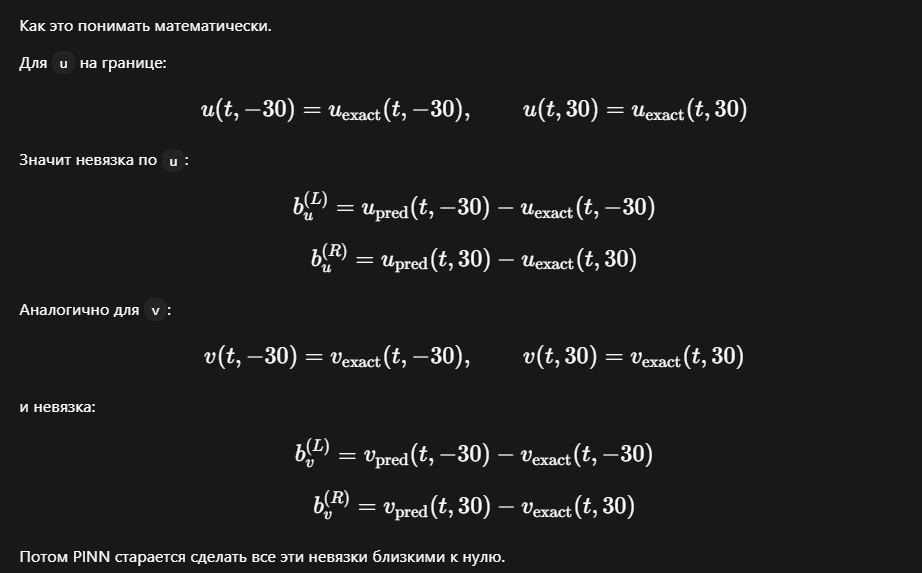

In [13]:
def residuals_from_fields(fields):
    """
    fields ????????:
    u, v, u_t, u_x, u_xx, v_t, v_x, v_xx
    """

    r_u = fields['u_t'] + us * fields['u'] * fields['u_x'] + fields['v'] + fields['v_xx']
    r_v = fields['v'] - fields['u_xx']

    return {
        'r_u': r_u,
        'r_v': r_v,
    }


def predict_uv(model_like, variant_name, X):
    with tf.device(TRAINING_DEVICE):
        if variant_name == 'two_models':
            u_pred = model_like['u'](X, training=False)
            v_pred = model_like['v'](X, training=False)
        else:
            y_pred = model_like(X, training=False)
            u_pred, v_pred = split_uv(y_pred)
    return u_pred, v_pred


def build_plot_grid(plot_times=None, num_x=PLOT_NUM_X):
    if plot_times is None:
        plot_times = [tmin, 0.5 * (tmin + tmax), tmax]

    dtype = tf.dtypes.as_dtype(DTYPE)
    x_plot = tf.reshape(
        tf.linspace(tf.cast(xmin, dtype), tf.cast(xmax, dtype), num_x),
        (-1, 1),
    )
    x_np = x_plot.numpy().squeeze()

    return dtype, [float(t) for t in plot_times], x_plot, x_np


def make_snapshot_metrics(metrics):
    if metrics is None:
        return None

    return {
        'total': float(metrics['total']),
        'phi_r': float(metrics['phi_r']),
        'phi_b': float(metrics['phi_b']),
        'phi_0': float(metrics['phi_0']),
    }


def format_snapshot_metrics(metrics):
    if metrics is None:
        return None

    return (
        f"total={metrics['total']:.2e}, "
        f"phi_r={metrics['phi_r']:.2e}, "
        f"phi_b={metrics['phi_b']:.2e}, "
        f"phi_0={metrics['phi_0']:.2e}"
    )


def collect_training_snapshot(model_like, variant_name, step, plot_times=None, num_x=PLOT_NUM_X, metrics=None):
    dtype, plot_times, x_plot, x_np = build_plot_grid(plot_times=plot_times, num_x=num_x)
    snapshot = {
        'step': int(step),
        'plot_times': plot_times,
        'x': x_np,
        'u_pred': [],
        'v_pred': [],
        'u_true': [],
        'v_true': [],
        'metrics': make_snapshot_metrics(metrics),
    }

    for t_scalar in plot_times:
        t_plot = tf.fill((num_x, 1), tf.cast(t_scalar, dtype))
        X_plot = stack_tx(t_plot, x_plot)

        u_pred, v_pred = predict_uv(model_like, variant_name, X_plot)
        u_true = u_exact(t_plot, x_plot)
        v_true = v_exact(t_plot, x_plot)

        snapshot['u_pred'].append(u_pred.numpy().squeeze())
        snapshot['v_pred'].append(v_pred.numpy().squeeze())
        snapshot['u_true'].append(u_true.numpy().squeeze())
        snapshot['v_true'].append(v_true.numpy().squeeze())

    return snapshot


def plot_training_snapshot(model_like=None, variant_name=None, step=None, plot_times=None, num_x=PLOT_NUM_X, metrics=None, snapshot=None):
    if snapshot is None:
        if model_like is None or variant_name is None or step is None:
            raise ValueError('model_like, variant_name and step are required when snapshot is not provided.')

        snapshot = collect_training_snapshot(
            model_like,
            variant_name,
            step,
            plot_times=plot_times,
            num_x=num_x,
            metrics=metrics,
        )
    elif variant_name is None:
        raise ValueError('variant_name is required.')

    x_np = np.asarray(snapshot['x'])
    plot_times = snapshot['plot_times']
    fig, axes = plt.subplots(2, len(plot_times), figsize=(5 * len(plot_times), 7), sharex=True, squeeze=False)

    title = f"{variant_name}: approximation at step {snapshot['step']}"
    metrics_text = format_snapshot_metrics(snapshot.get('metrics'))
    if metrics_text is not None:
        title = title + "\n" + metrics_text
    fig.suptitle(title, fontsize=14)

    for col, t_scalar in enumerate(plot_times):
        u_true_np = np.asarray(snapshot['u_true'][col])
        v_true_np = np.asarray(snapshot['v_true'][col])
        u_pred_np = np.asarray(snapshot['u_pred'][col])
        v_pred_np = np.asarray(snapshot['v_pred'][col])

        axes[0, col].plot(x_np, u_true_np, label='exact', lw=2)
        axes[0, col].plot(x_np, u_pred_np, '--', label='pred', lw=2)
        axes[0, col].set_title(f't = {t_scalar:.2f}')
        axes[0, col].set_ylabel('u(t, x)')
        axes[0, col].grid(True, alpha=0.3)

        axes[1, col].plot(x_np, v_true_np, label='exact', lw=2)
        axes[1, col].plot(x_np, v_pred_np, '--', label='pred', lw=2)
        axes[1, col].set_title(f't = {t_scalar:.2f}')
        axes[1, col].set_xlabel('x')
        axes[1, col].set_ylabel('v(t, x)')
        axes[1, col].grid(True, alpha=0.3)

    axes[0, 0].legend()
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

    return snapshot


def select_snapshots_for_plot(snapshots, max_snapshots=6):
    if not snapshots:
        return []

    if max_snapshots is None or len(snapshots) <= max_snapshots:
        return list(snapshots)

    idx = np.linspace(0, len(snapshots) - 1, max_snapshots)
    idx = np.unique(np.round(idx).astype(int))
    return [snapshots[i] for i in idx]


def plot_approximation_evolution(history, variant_name, max_snapshots=6):
    snapshots = history.get('snapshots', [])
    if not snapshots:
        raise ValueError('history does not contain snapshots. Run training with plot_every > 0.')

    snapshots_to_plot = select_snapshots_for_plot(snapshots, max_snapshots=max_snapshots)
    reference_snapshot = snapshots_to_plot[-1]
    x_np = np.asarray(reference_snapshot['x'])
    plot_times = reference_snapshot['plot_times']

    fig, axes = plt.subplots(2, len(plot_times), figsize=(5 * len(plot_times), 7), sharex=True, squeeze=False)
    fig.suptitle(f'{variant_name}: approximation evolution during training', fontsize=14)

    for row, field_name in enumerate(('u', 'v')):
        exact_key = f'{field_name}_true'
        pred_key = f'{field_name}_pred'

        for col, t_scalar in enumerate(plot_times):
            ax = axes[row, col]
            ax.plot(x_np, np.asarray(reference_snapshot[exact_key][col]), color='black', lw=2.5, label='exact')

            for snapshot in snapshots_to_plot:
                ax.plot(
                    x_np,
                    np.asarray(snapshot[pred_key][col]),
                    lw=1.4,
                    alpha=0.85,
                    label=f"step {snapshot['step']}",
                )

            ax.set_title(f't = {t_scalar:.2f}')
            ax.grid(True, alpha=0.3)
            if row == 1:
                ax.set_xlabel('x')
            if col == 0:
                ax.set_ylabel(f'{field_name}(t, x)')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=min(len(labels), 4), bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()


def boundary_residuals_from_exact(model_like, variant_name, X_lb, X_ub):

    t_lb, x_lb = X_lb[:, 0:1], X_lb[:, 1:2]
    t_ub, x_ub = X_ub[:, 0:1], X_ub[:, 1:2]

    u_lb_pred, v_lb_pred = predict_uv(model_like, variant_name, X_lb)
    u_ub_pred, v_ub_pred = predict_uv(model_like, variant_name, X_ub)

    u_lb_exact = u_exact(t_lb, x_lb)
    u_ub_exact = u_exact(t_ub, x_ub)

    v_lb_exact = v_exact(t_lb, x_lb)
    v_ub_exact = v_exact(t_ub, x_ub)

    b_u = tf.concat([
        u_lb_pred - u_lb_exact,
        u_ub_pred - u_ub_exact,
    ], axis=0)

    b_v = tf.concat([
        v_lb_pred - v_lb_exact,
        v_ub_pred - v_ub_exact,
    ], axis=0)

    return {
        'b_u': b_u,
        'b_v': b_v,
    }


## 11. Функция потерь для каждого варианта

In [14]:
def select_fields(model_like, variant_name, X):
    if variant_name == 'two_output':
        return derivatives_two_output_model(model_like, X)
    if variant_name == 'two_models':
        return derivatives_two_models(model_like['u'], model_like['v'], X)
    if variant_name == 'shared_trunk':
        return derivatives_two_output_model(model_like, X)
    raise ValueError(f'Unknown variant_name: {variant_name}')


def initial_condition_loss(model_like, variant_name, X_0, u_0, v_0):
    fields_0 = select_fields(model_like, variant_name, X_0)
    phi_0_u = mse(fields_0['u'] - u_0)
    phi_0_v = mse(fields_0['v'] - v_0)
    return {
        'phi_0_u': phi_0_u,
        'phi_0_v': phi_0_v,
        'phi_0': phi_0_u + phi_0_v,
    }


def compute_total_loss(model_like, variant_name, X_r, X_0, u_0, v_0, X_lb, X_ub):
    fields_r = select_fields(model_like, variant_name, X_r)
    residuals = residuals_from_fields(fields_r)
    bc = boundary_residuals_from_exact(model_like, variant_name, X_lb, X_ub)
    ic = initial_condition_loss(model_like, variant_name, X_0, u_0, v_0)

    phi_r = tf.add_n([mse(val) for val in residuals.values()])
    phi_b = tf.add_n([mse(val) for val in bc.values()])
    phi_0 = ic['phi_0']

    total_loss = lambda_r * phi_r + lambda_b * phi_b + lambda_0 * phi_0

    metrics = {
        'total': total_loss,
        'phi_r': phi_r,
        'phi_b': phi_b,
        'phi_0': phi_0,
    }
    metrics.update(ic)
    return total_loss, metrics


## 12. Шаг обучения и цикл тренировки

In [15]:
def trainable_variables_for_variant(model_like, variant_name):
    if variant_name == 'two_models':
        return model_like['u'].trainable_variables + model_like['v'].trainable_variables
    return model_like.trainable_variables


def build_variant_for_training(model_like, optimizer, variant_name):
    dtype = tf.dtypes.as_dtype(DTYPE)
    dummy_X = tf.zeros((1, 2), dtype=dtype)

    if variant_name == 'two_models':
        model_like['u'](dummy_X, training=False)
        model_like['v'](dummy_X, training=False)
    else:
        model_like(dummy_X, training=False)

    variables = list(trainable_variables_for_variant(model_like, variant_name))
    if hasattr(optimizer, 'build'):
        optimizer.build(variables)
    return variables


def make_train_step(model_like, optimizer, variant_name):
    build_variant_for_training(model_like, optimizer, variant_name)

    @tf.function(reduce_retracing=True)
    def train_step_fn(X_r, X_0, u_0, v_0, X_lb, X_ub):
        with tf.device(TRAINING_DEVICE):
            with tf.GradientTape() as tape:
                total_loss, metrics = compute_total_loss(model_like, variant_name, X_r, X_0, u_0, v_0, X_lb, X_ub)

            variables = tuple(trainable_variables_for_variant(model_like, variant_name))
            grads = tape.gradient(total_loss, variables)
            grads_and_vars = [(grad, var) for grad, var in zip(grads, variables) if grad is not None]
            if grads_and_vars:
                optimizer.apply_gradients(grads_and_vars)
        return metrics

    return train_step_fn


def run_training(model_like, optimizer, variant_name, num_steps=NUM_STEPS, print_every=PRINT_EVERY, plot_every=PLOT_EVERY, plot_times=None, plot_num_x=PLOT_NUM_X):
    history = {
        'step': [],
        'total': [],
        'phi_r': [],
        'phi_b': [],
        'phi_0': [],
        'snapshots': [],
    }

    print(f'[{variant_name}] training device: {TRAINING_DEVICE}')
    train_step_fn = make_train_step(model_like, optimizer, variant_name)
    t0 = time()
    for step in range(num_steps + 1):
        metrics = train_step_fn(X_r, X_0, u_0, v_0, X_lb, X_ub)

        history['step'].append(step)
        history['total'].append(float(metrics['total']))
        history['phi_r'].append(float(metrics['phi_r']))
        history['phi_b'].append(float(metrics['phi_b']))
        history['phi_0'].append(float(metrics['phi_0']))

        if step % print_every == 0:
            print(f"[{variant_name}] step={step:05d} total={float(metrics['total']):.6e}")

        if plot_every and step >= 0 and step % plot_every == 0:
            snapshot = collect_training_snapshot(
                model_like,
                variant_name,
                step,
                plot_times=plot_times,
                num_x=plot_num_x,
                metrics=metrics,
            )
            history['snapshots'].append(snapshot)
            plot_training_snapshot(variant_name=variant_name, snapshot=snapshot)

    print(f'[{variant_name}] elapsed: {time() - t0:.2f} sec')
    return history


## 13. Инициализация трех подходов

In [16]:
with tf.device(TRAINING_DEVICE):
    two_output_model = TwoOutputPINN(
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        hidden_dim=HIDDEN_DIM,
        num_fourier=NUM_FOURIER,
        activation=ACTIVATION,
    )
    two_output_optim = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    two_models = {
        'u': SingleOutputPINN(
            num_hidden_layers=NUM_HIDDEN_LAYERS,
            hidden_dim=HIDDEN_DIM,
            num_fourier=NUM_FOURIER,
            activation=ACTIVATION,
            name='model_u',
        ),
        'v': SingleOutputPINN(
            num_hidden_layers=NUM_HIDDEN_LAYERS,
            hidden_dim=HIDDEN_DIM,
            num_fourier=NUM_FOURIER,
            activation=ACTIVATION,
            name='model_v',
        ),
    }
    two_models_optim = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    shared_trunk_model = SharedTrunkPINN(
        num_shared_layers=NUM_SHARED_LAYERS,
        hidden_dim=HIDDEN_DIM,
        num_fourier=NUM_FOURIER,
        activation=ACTIVATION,
    )
    shared_trunk_optim = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)


TypeError: SharedTrunkPINN.__init__() got an unexpected keyword argument 'num_shared_layers'

## 14. Запуск экспериментов



[two_output] training device: /CPU:0
[two_output] step=00000 total=1.840378e+00


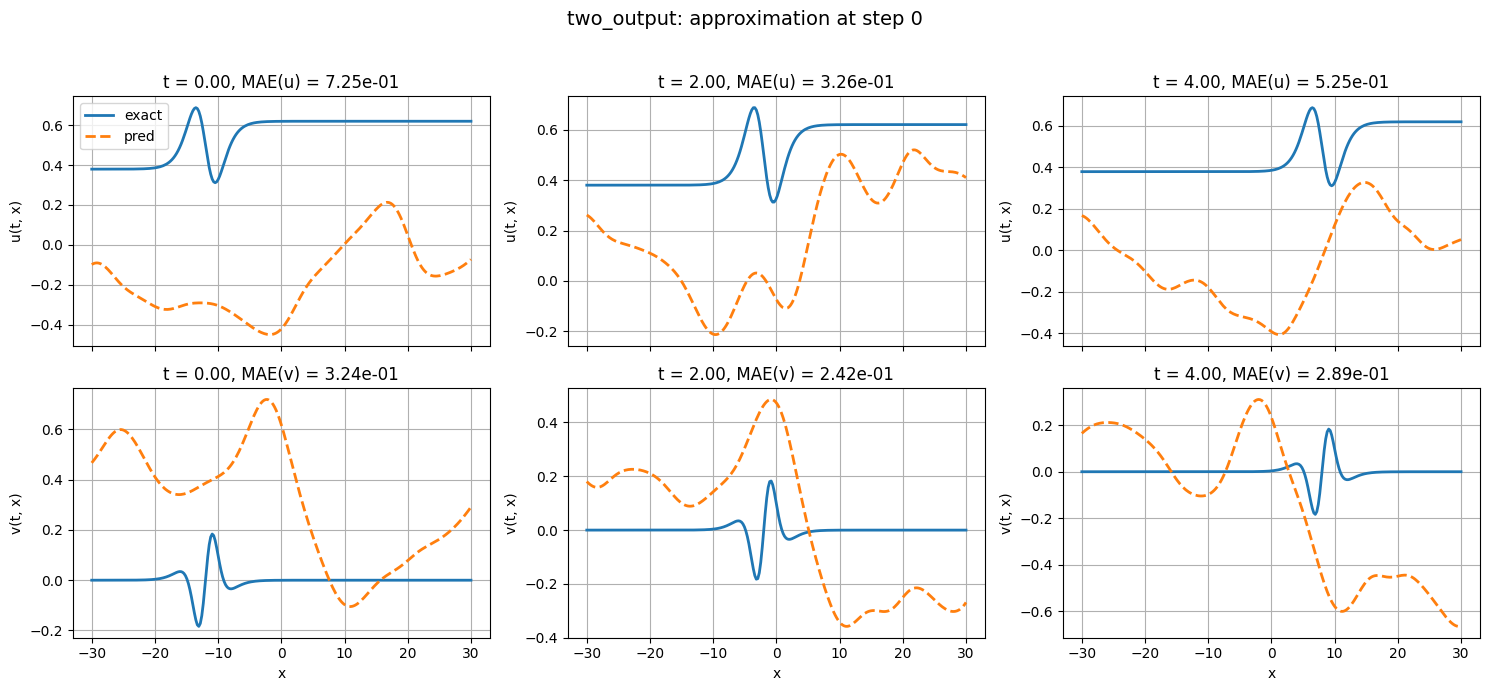

[two_output] step=00100 total=1.886244e-02
[two_output] step=00200 total=9.476698e-03
[two_output] step=00300 total=6.742308e-03
[two_output] step=00400 total=5.484751e-03
[two_output] step=00500 total=4.739971e-03
[two_output] step=00600 total=4.242866e-03
[two_output] step=00700 total=3.885108e-03
[two_output] step=00800 total=3.612908e-03
[two_output] step=00900 total=3.396399e-03
[two_output] step=01000 total=3.217623e-03


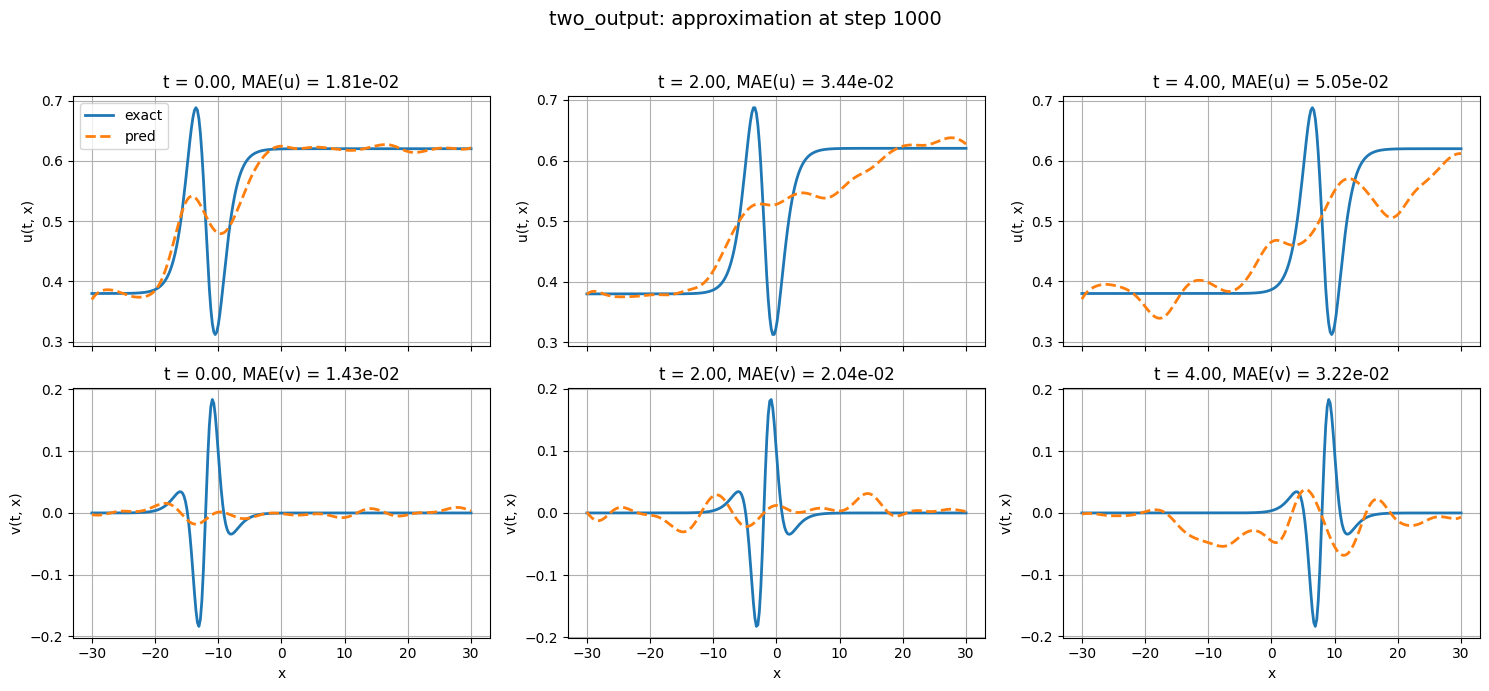

[two_output] step=01100 total=3.065188e-03
[two_output] step=01200 total=2.931623e-03
[two_output] step=01300 total=2.811911e-03
[two_output] step=01400 total=2.702621e-03
[two_output] step=01500 total=2.601370e-03
[two_output] step=01600 total=2.506470e-03
[two_output] step=01700 total=2.416682e-03
[two_output] step=01800 total=2.331056e-03
[two_output] step=01900 total=2.248797e-03
[two_output] step=02000 total=2.169180e-03


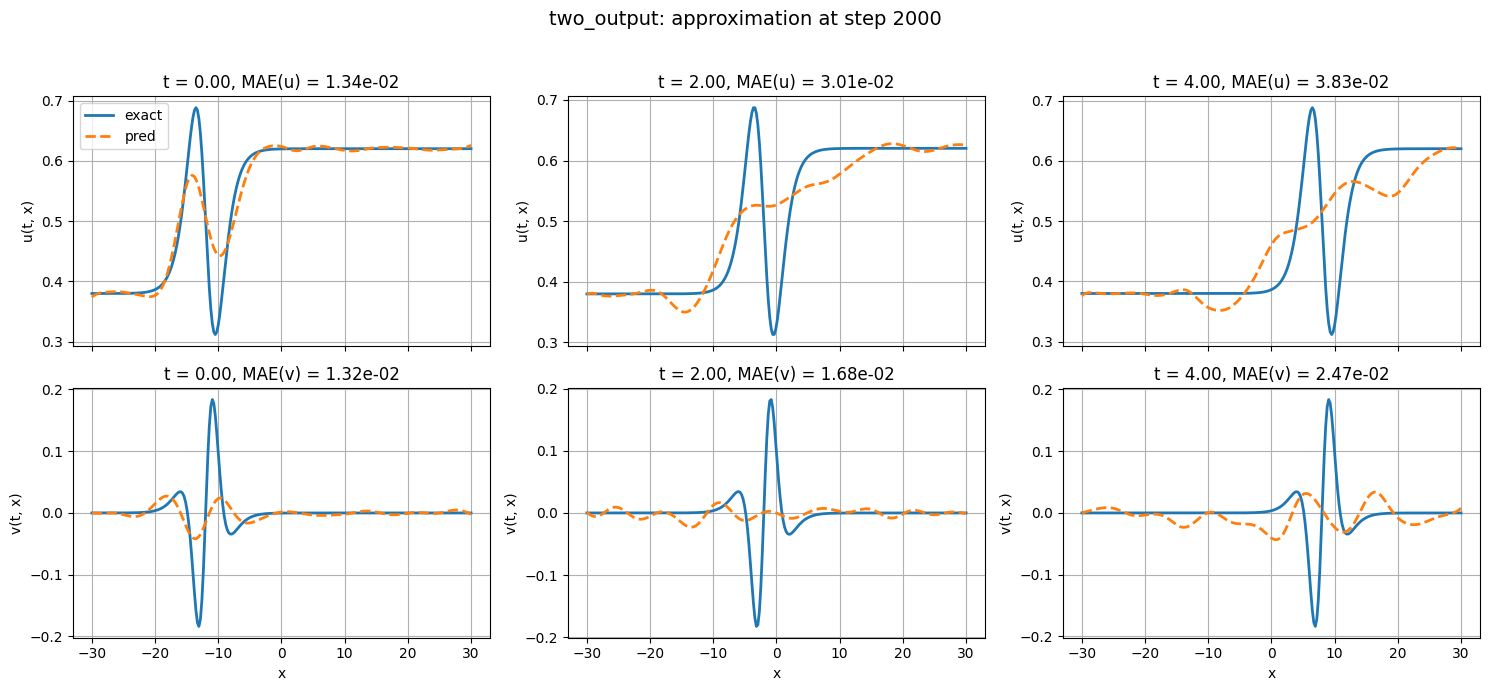

[two_output] step=02100 total=2.091484e-03
[two_output] step=02200 total=2.014960e-03
[two_output] step=02300 total=1.938833e-03
[two_output] step=02400 total=1.862323e-03
[two_output] step=02500 total=1.784704e-03
[two_output] step=02600 total=1.705380e-03
[two_output] step=02700 total=1.623972e-03
[two_output] step=02800 total=1.540408e-03
[two_output] step=02900 total=1.454988e-03
[two_output] step=03000 total=1.368381e-03


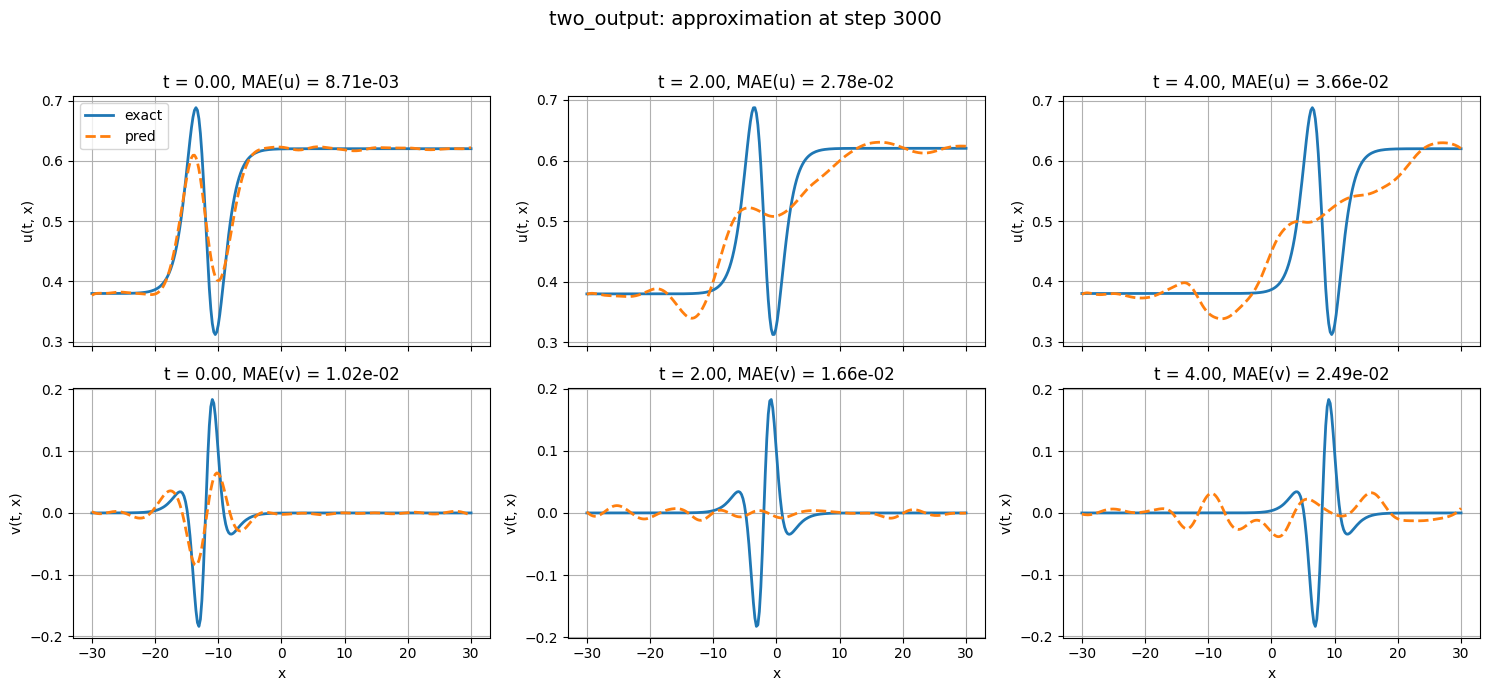

[two_output] step=03100 total=1.281536e-03
[two_output] step=03200 total=1.195532e-03
[two_output] step=03300 total=1.111446e-03
[two_output] step=03400 total=1.030283e-03
[two_output] step=03500 total=9.529654e-04
[two_output] step=03600 total=8.803252e-04
[two_output] step=03700 total=8.130446e-04
[two_output] step=03800 total=7.515670e-04
[two_output] step=03900 total=6.960333e-04
[two_output] step=04000 total=6.462862e-04


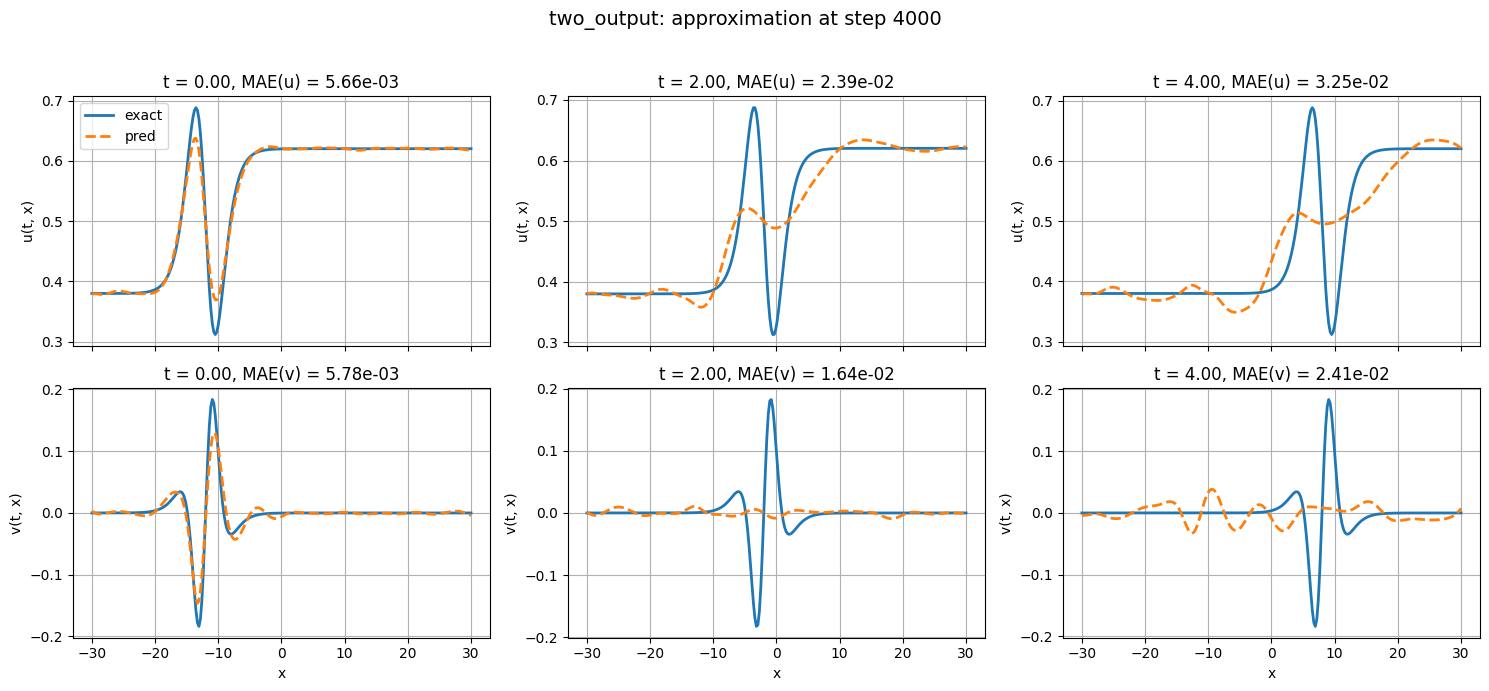

[two_output] step=04100 total=6.019387e-04
[two_output] step=04200 total=5.624728e-04
[two_output] step=04300 total=5.292577e-04
[two_output] step=04400 total=5.003216e-04
[two_output] step=04500 total=4.741500e-04
[two_output] step=04600 total=4.504287e-04
[two_output] step=04700 total=6.918149e-04
[two_output] step=04800 total=4.109306e-04
[two_output] step=04900 total=3.944287e-04
[two_output] step=05000 total=3.793148e-04


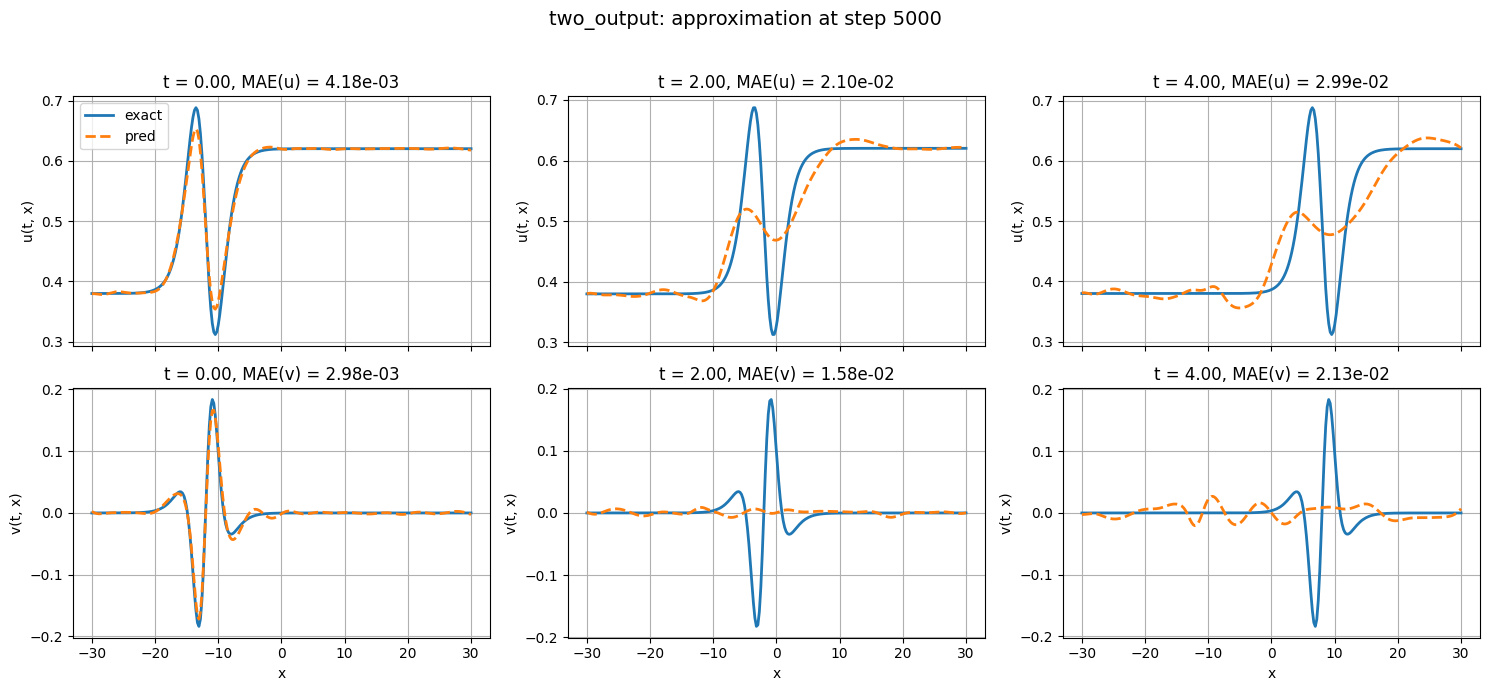

[two_output] step=05100 total=3.654638e-04
[two_output] step=05200 total=3.536073e-04
[two_output] step=05300 total=3.424941e-04
[two_output] step=05400 total=3.323436e-04
[two_output] step=05500 total=3.229062e-04
[two_output] step=05600 total=3.146554e-04
[two_output] step=05700 total=3.069614e-04
[two_output] step=05800 total=2.998184e-04
[two_output] step=05900 total=2.930792e-04
[two_output] step=06000 total=2.892239e-04


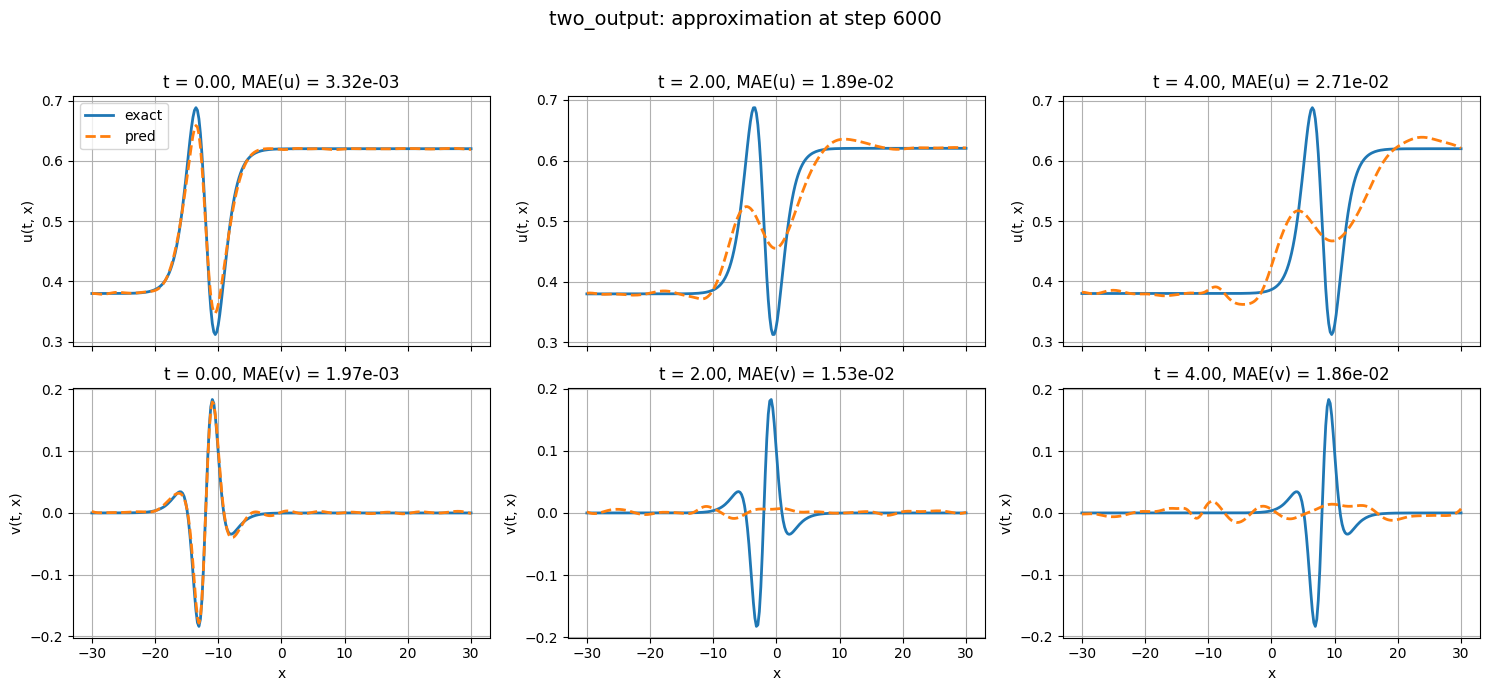

[two_output] step=06100 total=2.814243e-04
[two_output] step=06200 total=3.635180e-04
[two_output] step=06300 total=2.712711e-04
[two_output] step=06400 total=2.666029e-04
[two_output] step=06500 total=2.639376e-04
[two_output] step=06600 total=2.671246e-04
[two_output] step=06700 total=2.543880e-04
[two_output] step=06800 total=2.545755e-04
[two_output] step=06900 total=2.708701e-04
[two_output] step=07000 total=2.437672e-04


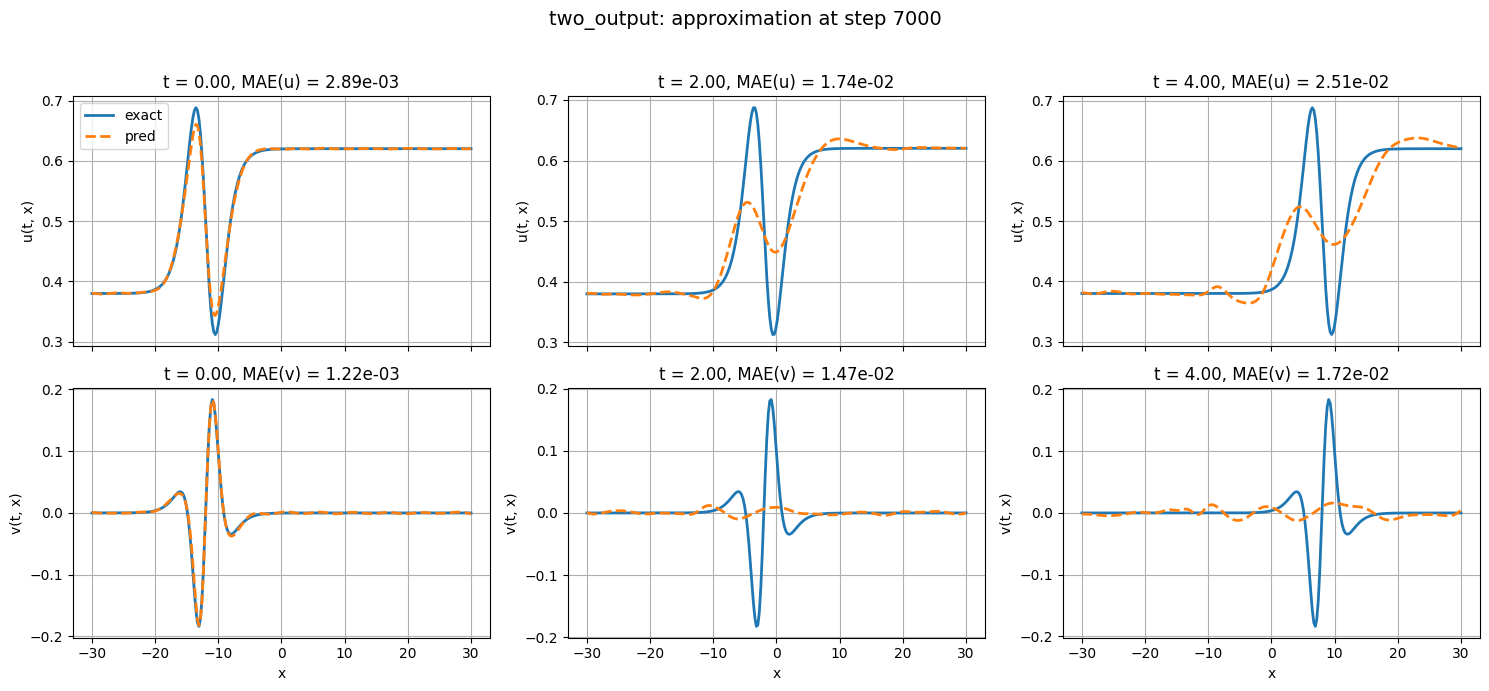

[two_output] step=07100 total=2.405236e-04
[two_output] step=07200 total=2.373390e-04
[two_output] step=07300 total=2.344105e-04
[two_output] step=07400 total=2.315295e-04
[two_output] step=07500 total=2.286244e-04
[two_output] step=07600 total=2.646085e-04
[two_output] step=07700 total=2.231050e-04
[two_output] step=07800 total=2.206055e-04
[two_output] step=07900 total=2.178041e-04
[two_output] step=08000 total=2.156843e-04


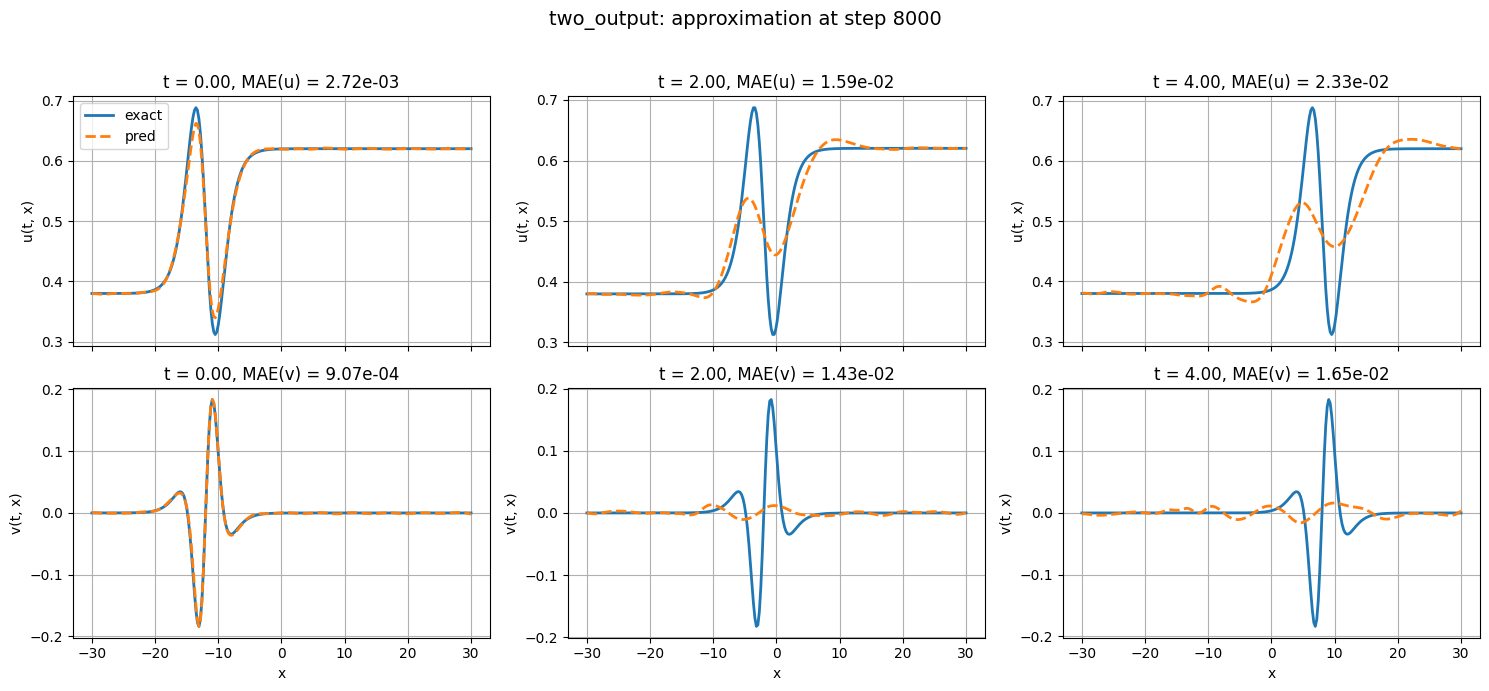

[two_output] step=08100 total=2.135250e-04
[two_output] step=08200 total=2.230431e-04
[two_output] step=08300 total=2.078560e-04
[two_output] step=08400 total=2.055258e-04
[two_output] step=08500 total=2.032188e-04
[two_output] step=08600 total=2.899811e-04
[two_output] step=08700 total=2.027097e-04
[two_output] step=08800 total=2.022186e-04
[two_output] step=08900 total=3.136457e-04
[two_output] step=09000 total=2.157536e-04


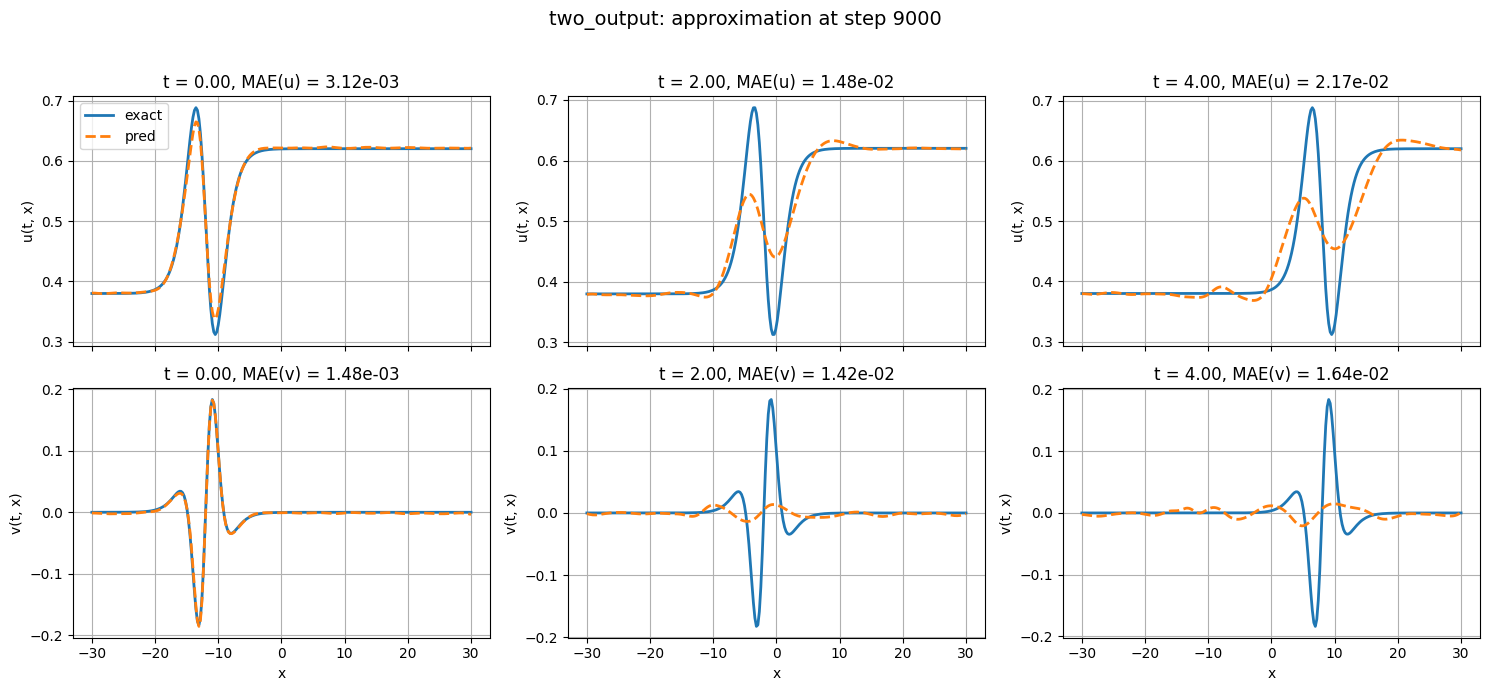

[two_output] step=09100 total=1.899254e-04
[two_output] step=09200 total=1.884543e-04
[two_output] step=09300 total=1.866285e-04
[two_output] step=09400 total=2.683751e-04
[two_output] step=09500 total=1.832428e-04
[two_output] step=09600 total=1.801012e-04
[two_output] step=09700 total=1.790537e-04
[two_output] step=09800 total=1.781673e-04
[two_output] step=09900 total=2.990913e-04
[two_output] step=10000 total=1.729578e-04


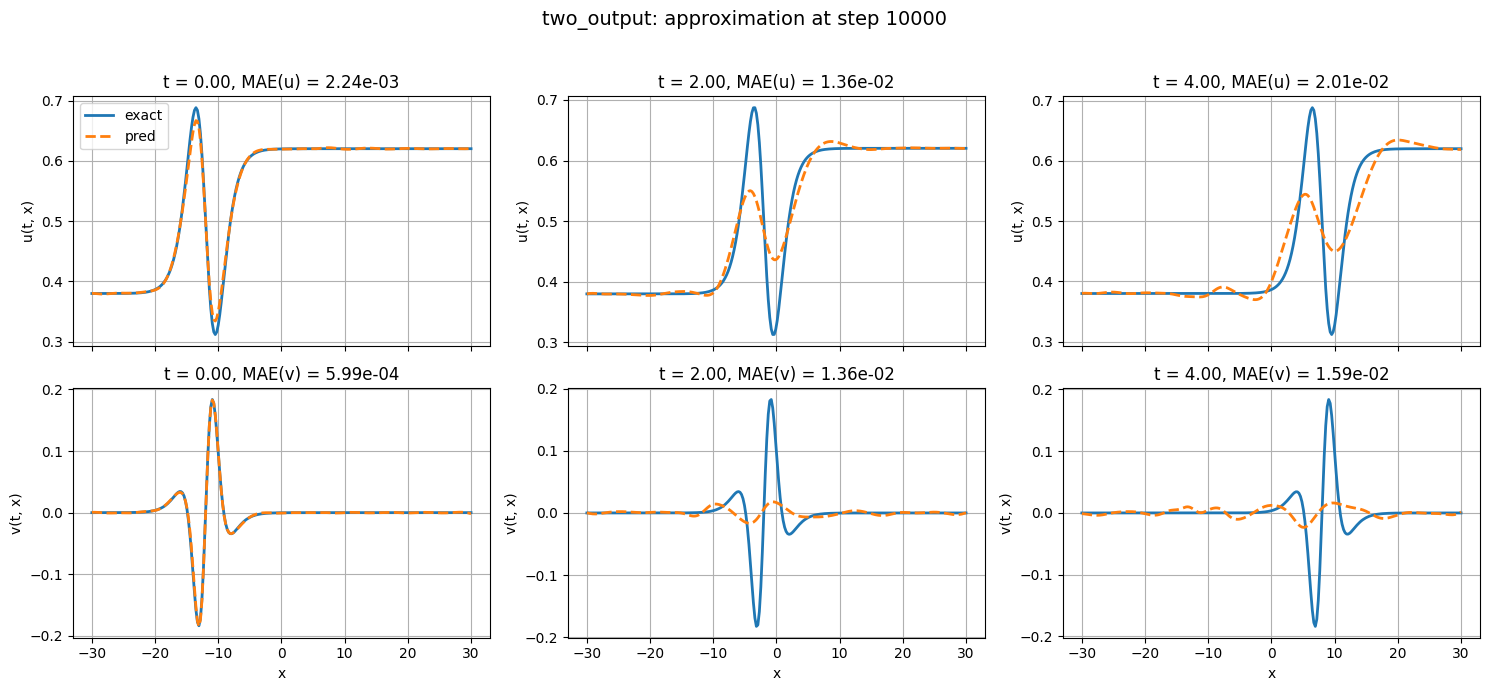

[two_output] step=10100 total=1.717274e-04
[two_output] step=10200 total=2.203276e-04
[two_output] step=10300 total=1.680206e-04
[two_output] step=10400 total=3.315913e-04
[two_output] step=10500 total=1.648621e-04
[two_output] step=10600 total=1.640692e-04
[two_output] step=10700 total=1.618827e-04
[two_output] step=10800 total=1.655624e-04
[two_output] step=10900 total=1.590880e-04
[two_output] step=11000 total=1.576443e-04


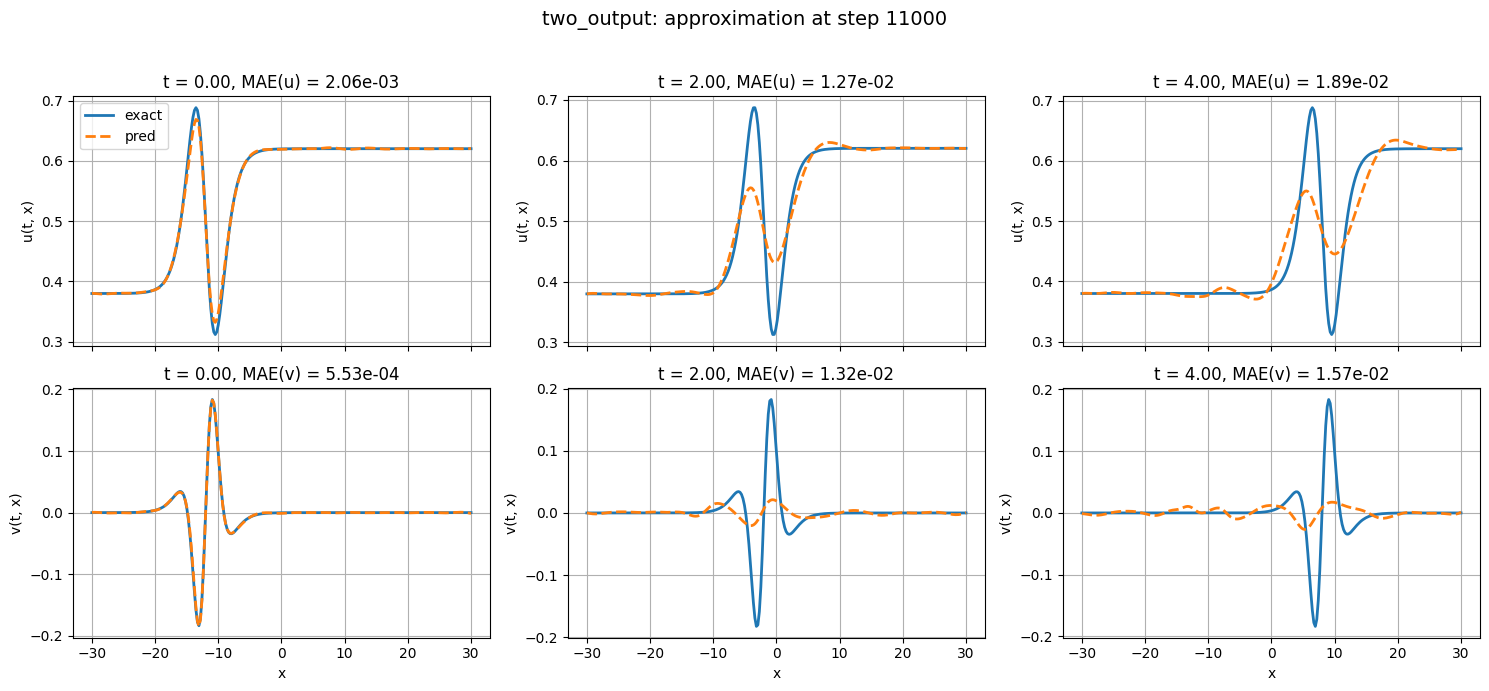

[two_output] step=11100 total=1.565783e-04
[two_output] step=11200 total=1.549646e-04
[two_output] step=11300 total=1.541297e-04
[two_output] step=11400 total=1.523899e-04
[two_output] step=11500 total=1.510385e-04
[two_output] step=11600 total=1.517759e-04
[two_output] step=11700 total=1.494562e-04
[two_output] step=11800 total=1.473187e-04
[two_output] step=11900 total=1.481761e-04
[two_output] step=12000 total=1.448765e-04


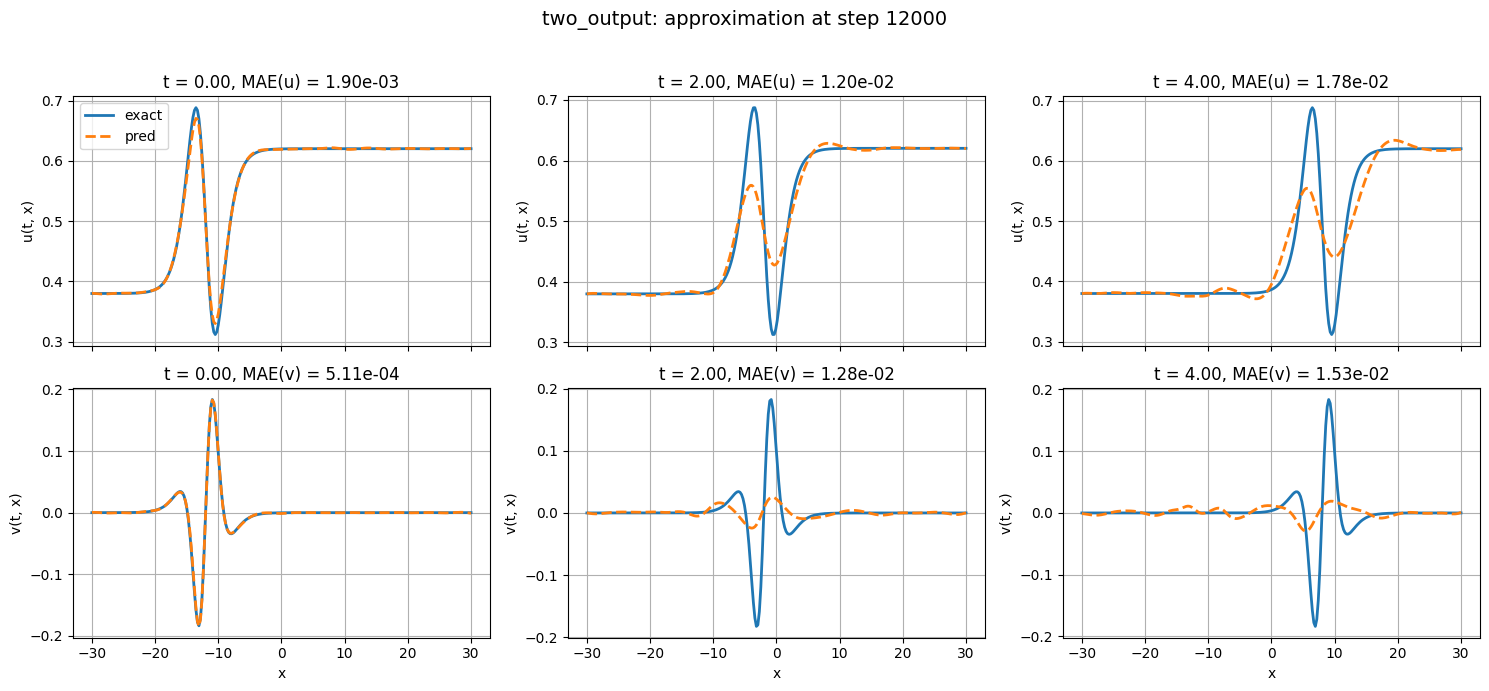

[two_output] step=12100 total=1.709714e-04
[two_output] step=12200 total=1.510547e-04
[two_output] step=12300 total=1.413138e-04
[two_output] step=12400 total=1.402348e-04
[two_output] step=12500 total=1.389287e-04
[two_output] step=12600 total=1.996619e-04
[two_output] step=12700 total=1.366677e-04
[two_output] step=12800 total=1.451977e-04
[two_output] step=12900 total=1.343782e-04
[two_output] step=13000 total=1.332877e-04


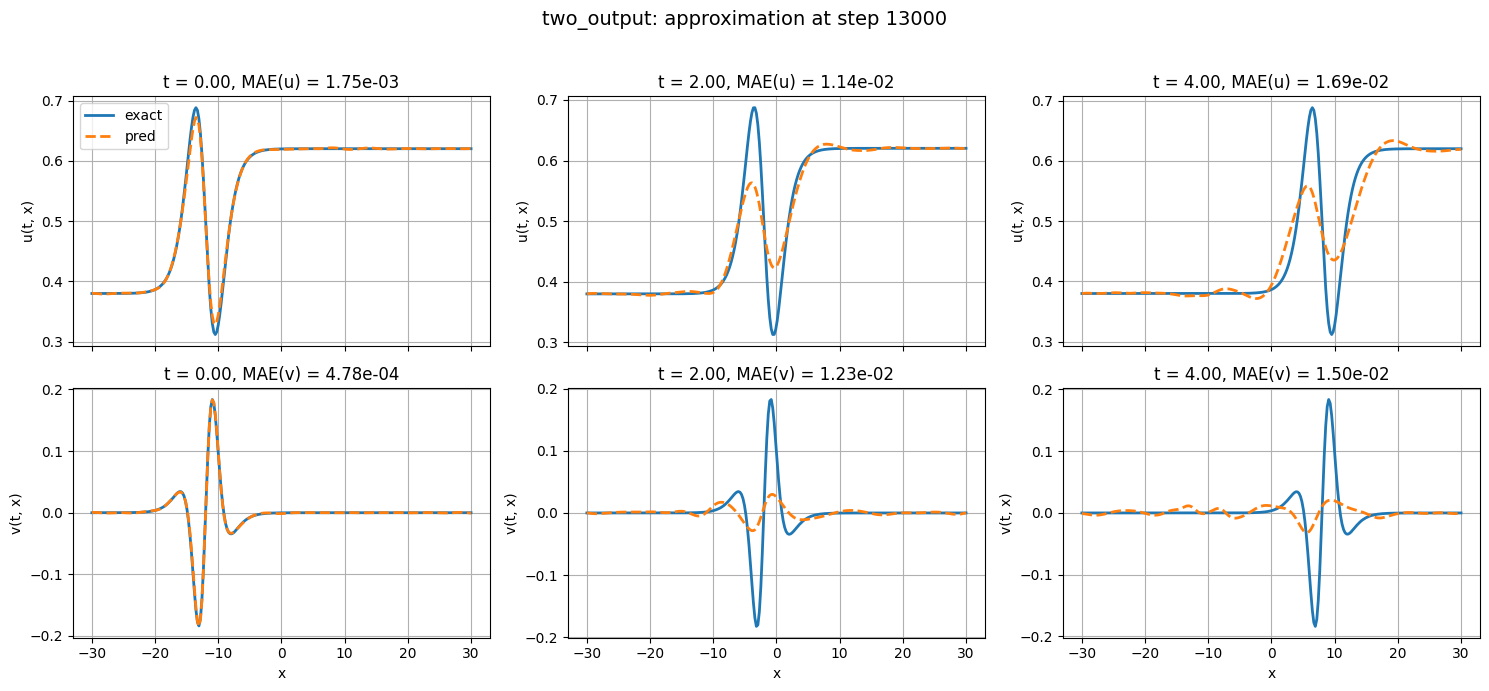

[two_output] elapsed: 10776.78 sec
[two_models] training device: /CPU:0
[two_models] step=00000 total=1.738430e+00


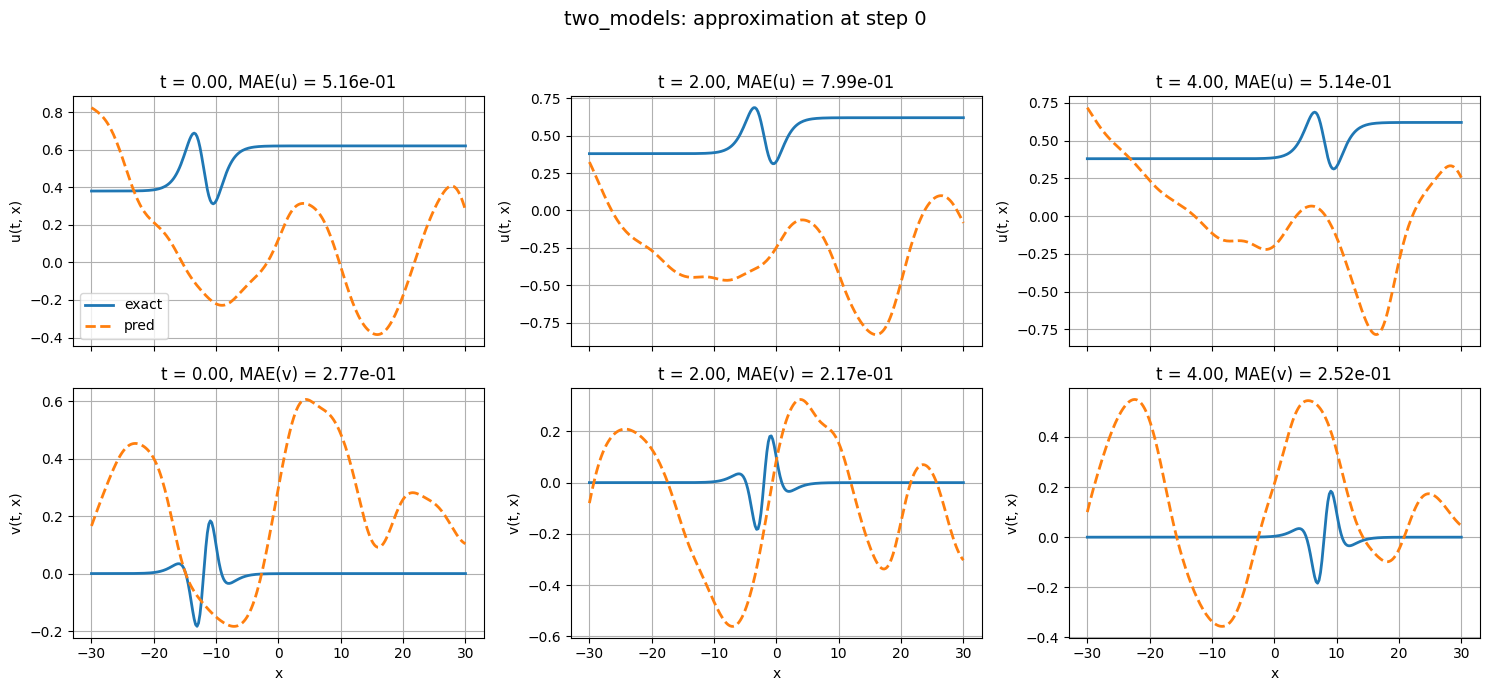

[two_models] step=00100 total=1.345931e-02
[two_models] step=00200 total=6.870370e-03
[two_models] step=00300 total=4.883193e-03
[two_models] step=00400 total=4.011387e-03
[two_models] step=00500 total=3.504357e-03
[two_models] step=00600 total=3.155251e-03
[two_models] step=00700 total=2.890211e-03
[two_models] step=00800 total=2.675585e-03
[two_models] step=00900 total=2.493484e-03
[two_models] step=01000 total=2.333339e-03


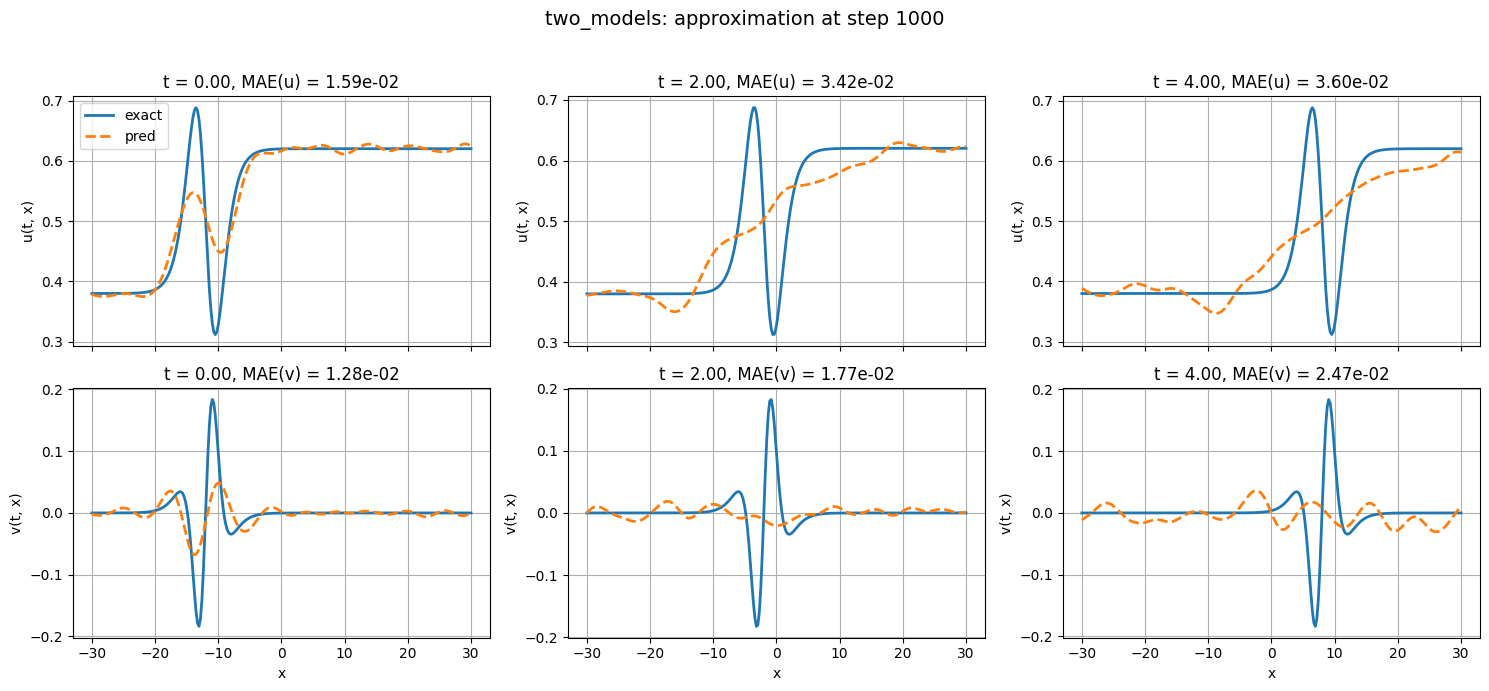

[two_models] step=01100 total=2.188390e-03
[two_models] step=01200 total=2.054100e-03
[two_models] step=01300 total=1.927388e-03
[two_models] step=01400 total=1.806267e-03
[two_models] step=01500 total=1.689690e-03
[two_models] step=01600 total=1.577478e-03
[two_models] step=01700 total=1.470210e-03
[two_models] step=01800 total=1.368996e-03
[two_models] step=01900 total=1.275152e-03
[two_models] step=02000 total=1.189822e-03


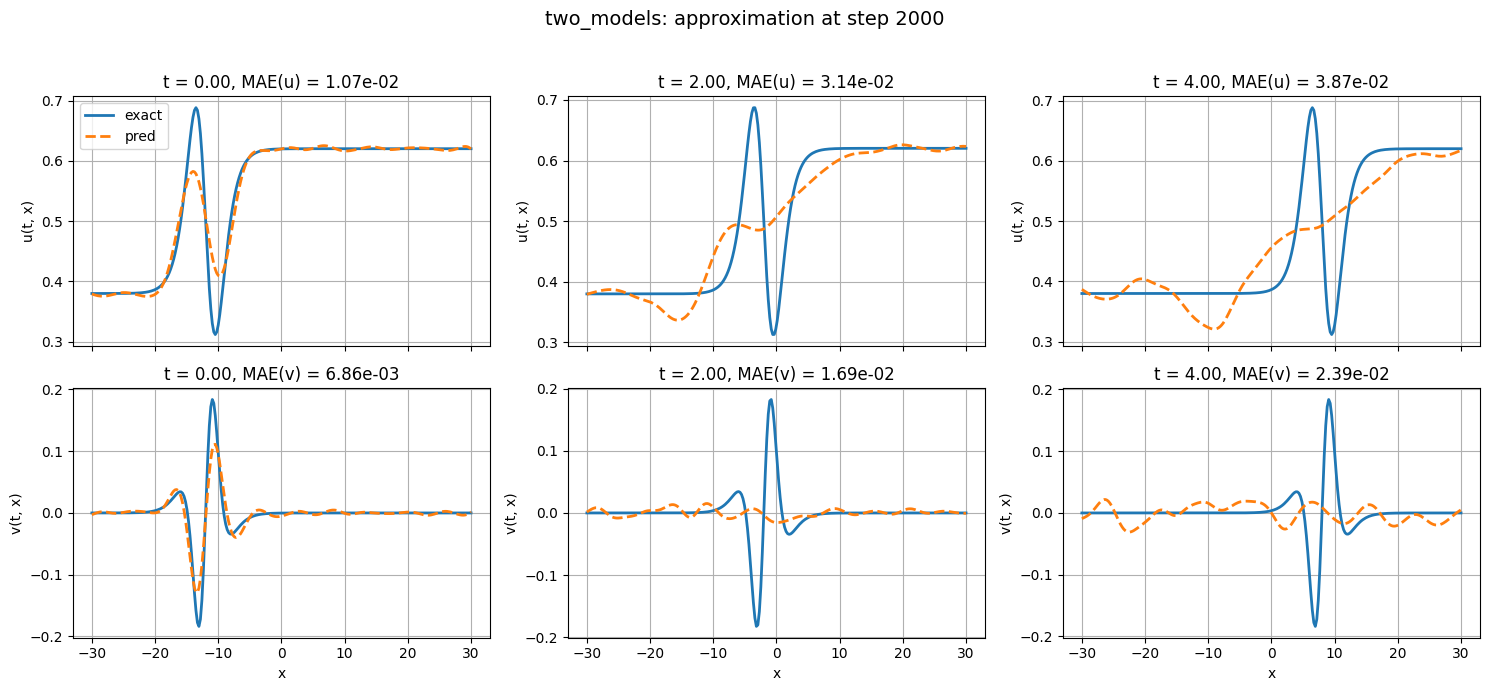

[two_models] step=02100 total=1.113621e-03
[two_models] step=02200 total=1.046408e-03
[two_models] step=02300 total=9.872965e-04
[two_models] step=02400 total=9.349338e-04
[two_models] step=02500 total=8.878962e-04
[two_models] step=02600 total=8.449837e-04
[two_models] step=02700 total=8.053227e-04
[two_models] step=02800 total=7.683280e-04
[two_models] step=02900 total=7.336178e-04
[two_models] step=03000 total=7.009400e-04


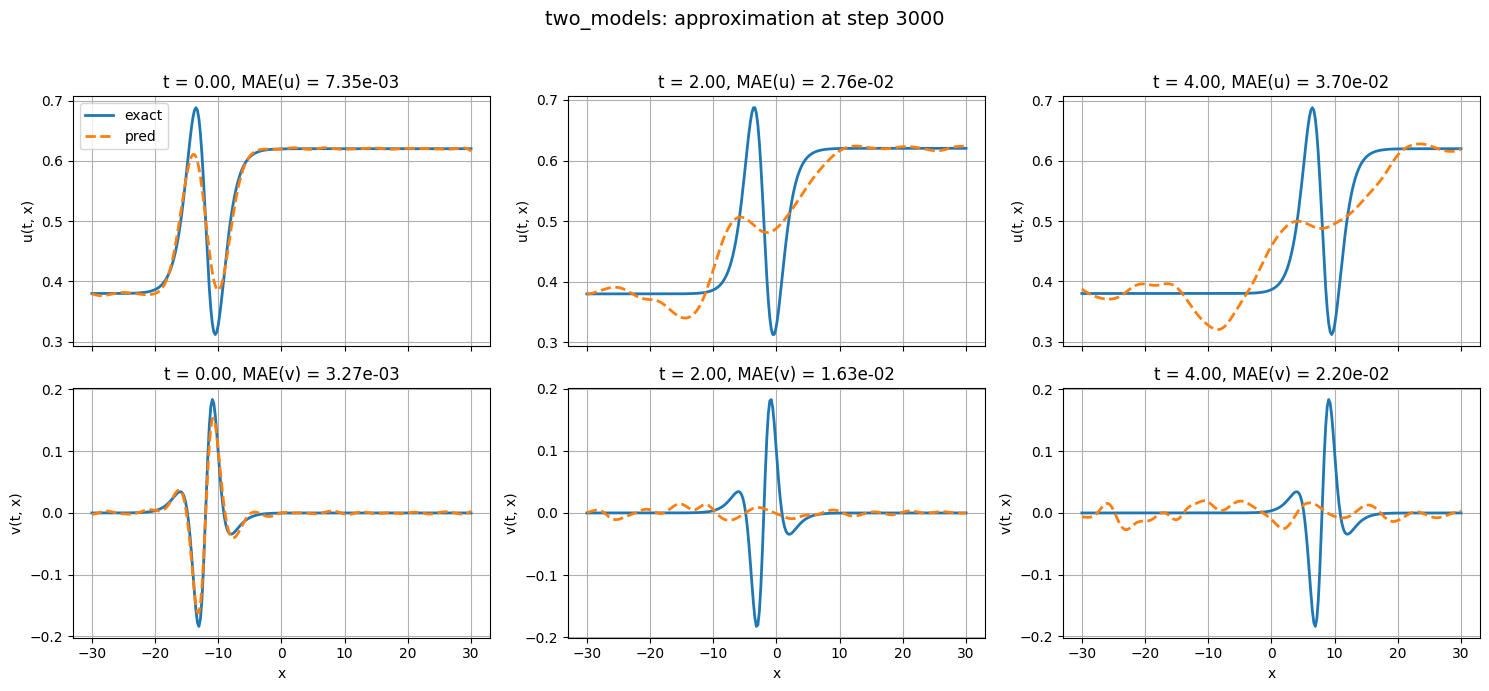

[two_models] step=03100 total=6.701205e-04
[two_models] step=03200 total=6.410309e-04
[two_models] step=03300 total=6.142488e-04
[two_models] step=03400 total=5.890369e-04
[two_models] step=03500 total=5.652180e-04
[two_models] step=03600 total=5.427193e-04
[two_models] step=03700 total=9.173261e-04
[two_models] step=03800 total=5.021586e-04
[two_models] step=03900 total=4.838414e-04
[two_models] step=04000 total=4.665795e-04


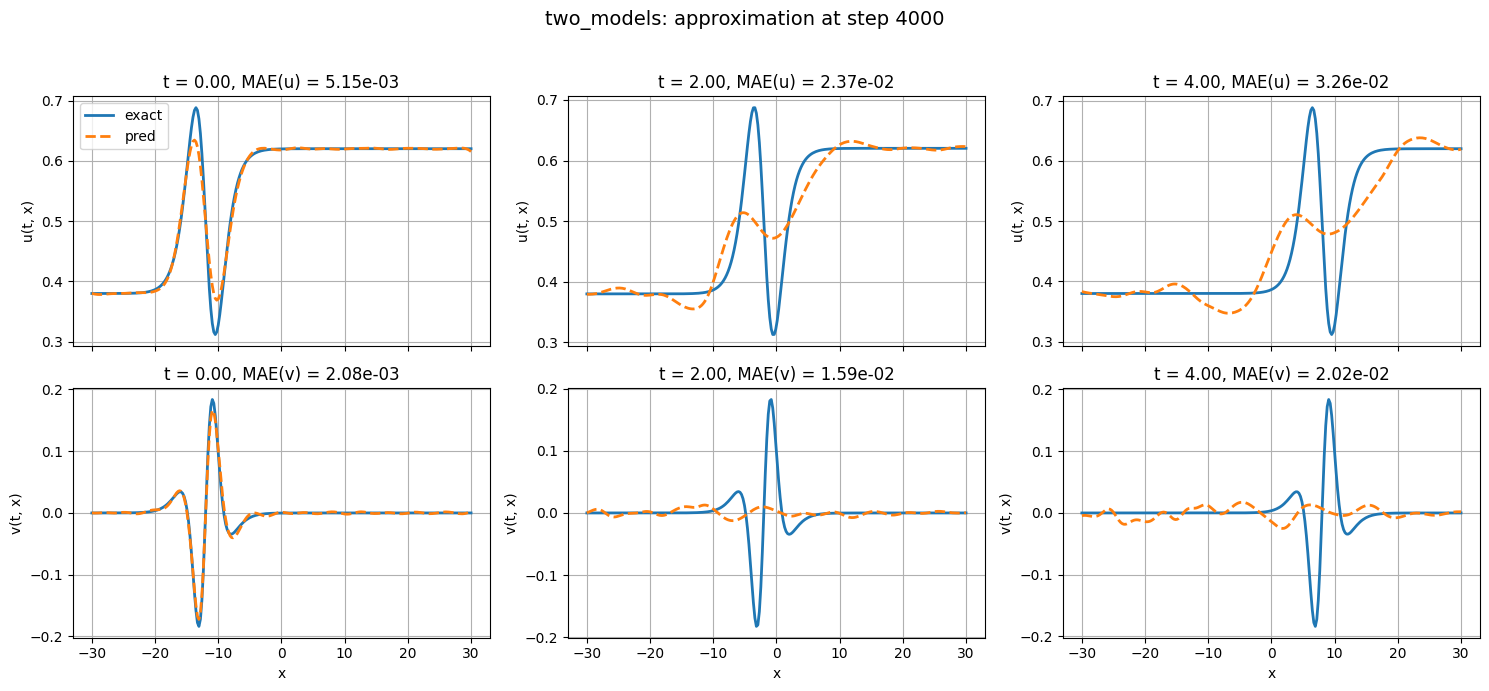

[two_models] step=04100 total=4.503219e-04
[two_models] step=04200 total=4.359675e-04
[two_models] step=04300 total=4.216246e-04
[two_models] step=04400 total=4.086072e-04
[two_models] step=04500 total=3.963411e-04
[two_models] step=04600 total=4.145760e-04
[two_models] step=04700 total=3.748092e-04
[two_models] step=04800 total=3.650310e-04
[two_models] step=04900 total=3.557017e-04
[two_models] step=05000 total=3.474089e-04


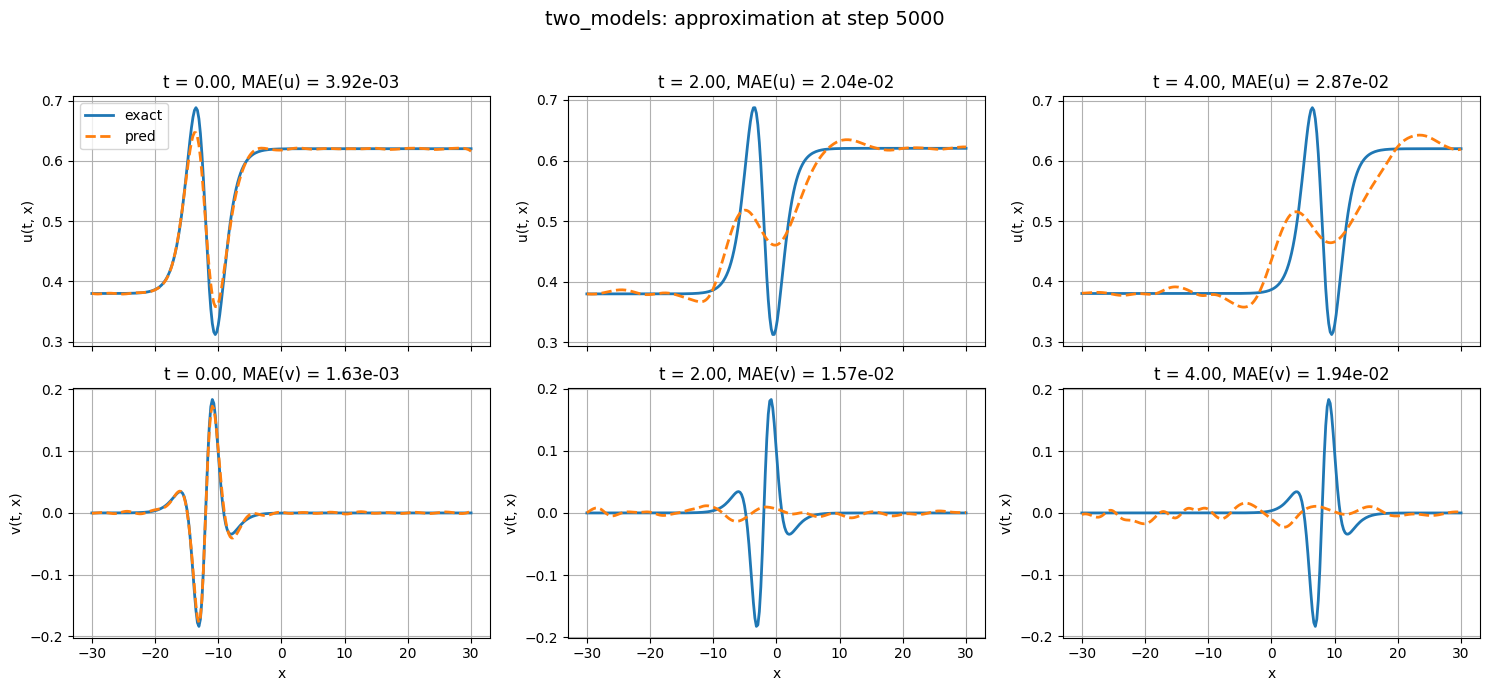

[two_models] step=05100 total=3.403460e-04
[two_models] step=05200 total=3.316138e-04
[two_models] step=05300 total=3.242753e-04
[two_models] step=05400 total=3.246210e-04
[two_models] step=05500 total=3.107694e-04
[two_models] step=05600 total=3.100351e-04
[two_models] step=05700 total=3.942376e-04
[two_models] step=05800 total=3.378303e-04
[two_models] step=05900 total=2.886628e-04
[two_models] step=06000 total=2.860765e-04


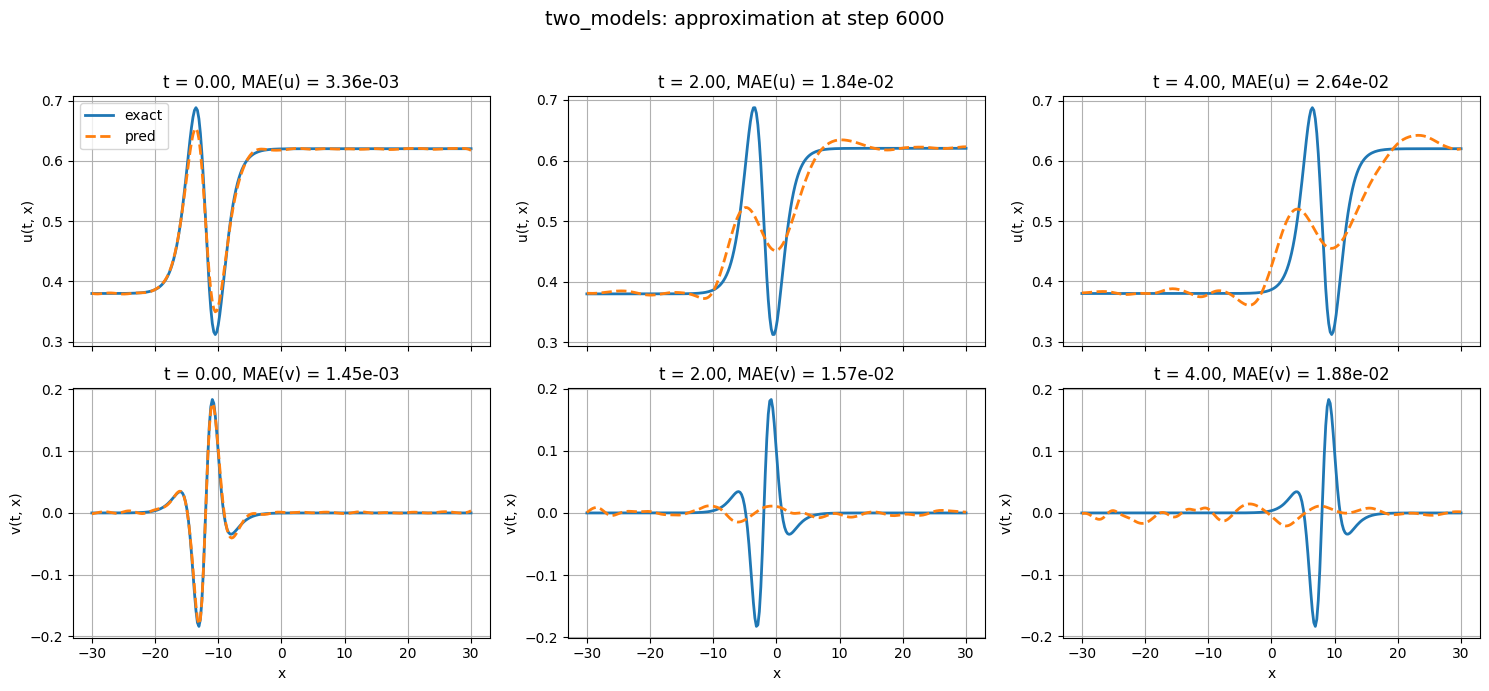

[two_models] step=06100 total=3.267139e-04
[two_models] step=06200 total=2.711104e-04
[two_models] step=06300 total=4.733520e-04
[two_models] step=06400 total=3.194840e-04
[two_models] step=06500 total=3.115605e-04
[two_models] step=06600 total=2.723640e-04
[two_models] step=06700 total=2.559912e-04
[two_models] step=06800 total=2.463488e-04
[two_models] step=06900 total=2.520536e-04
[two_models] step=07000 total=2.338234e-04


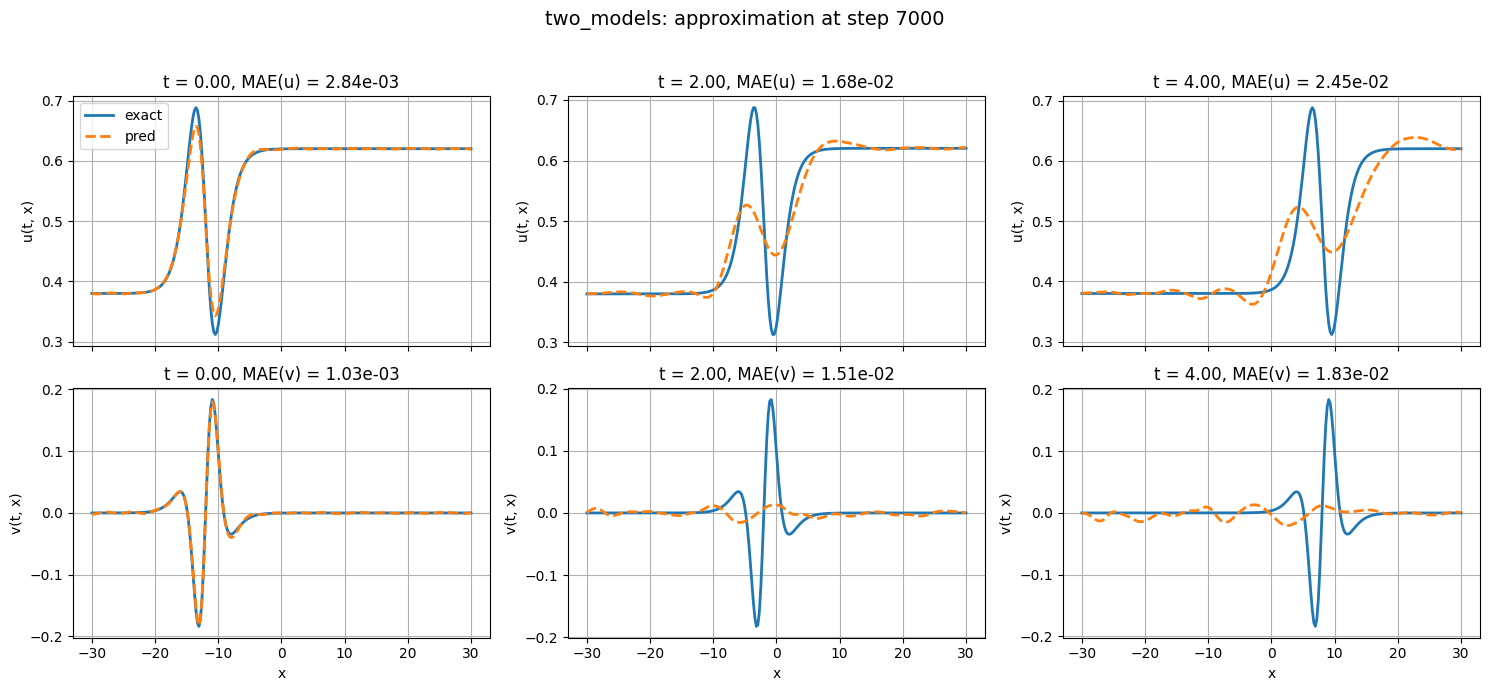

[two_models] step=07100 total=2.309283e-04
[two_models] step=07200 total=2.910010e-04
[two_models] step=07300 total=2.463092e-04
[two_models] step=07400 total=2.197735e-04
[two_models] step=07500 total=2.166387e-04
[two_models] step=07600 total=2.132396e-04
[two_models] step=07700 total=2.515971e-04
[two_models] step=07800 total=2.091741e-04
[two_models] step=07900 total=2.063536e-04
[two_models] step=08000 total=2.053072e-04


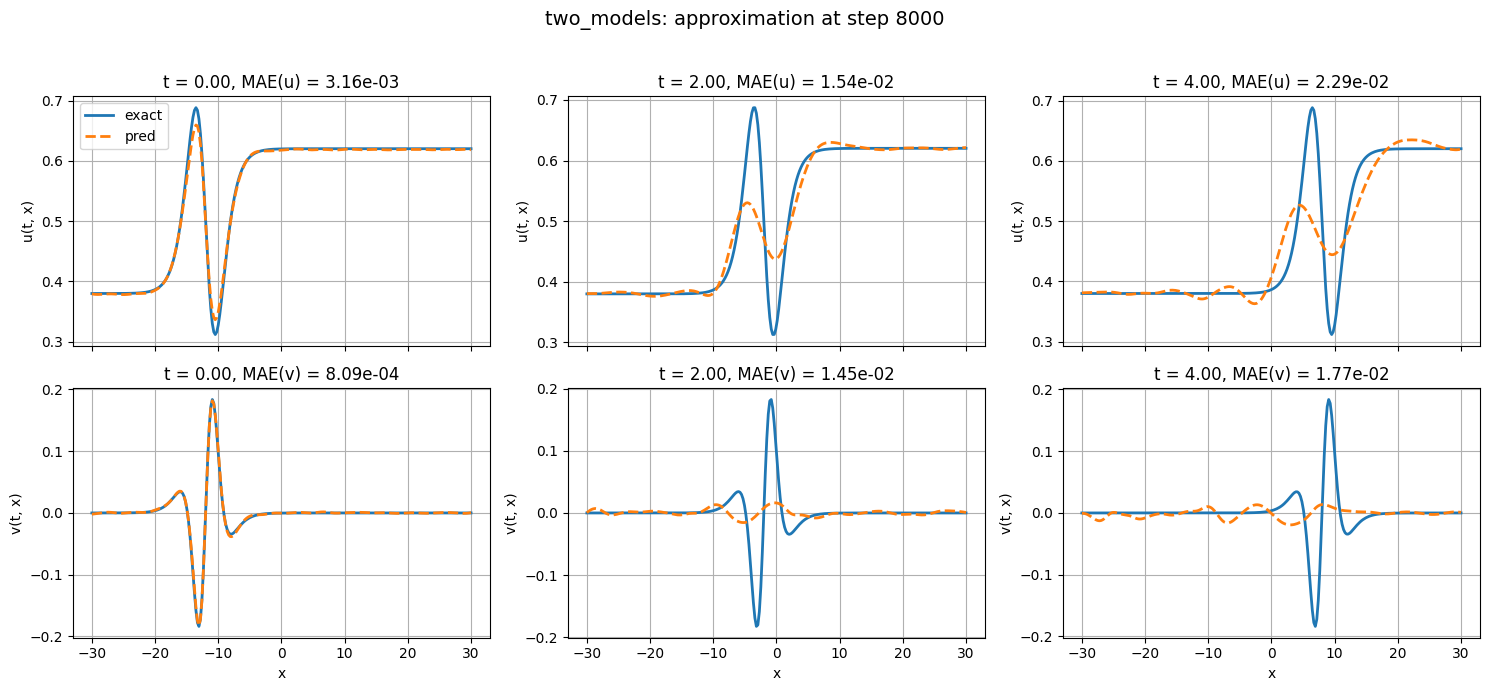

[two_models] step=08100 total=2.289957e-04
[two_models] step=08200 total=2.088665e-04
[two_models] step=08300 total=2.809773e-04
[two_models] step=08400 total=1.954491e-04
[two_models] step=08500 total=1.912055e-04
[two_models] step=08600 total=2.228011e-04
[two_models] step=08700 total=1.903397e-04
[two_models] step=08800 total=1.899937e-04
[two_models] step=08900 total=1.948126e-04
[two_models] step=09000 total=1.817657e-04


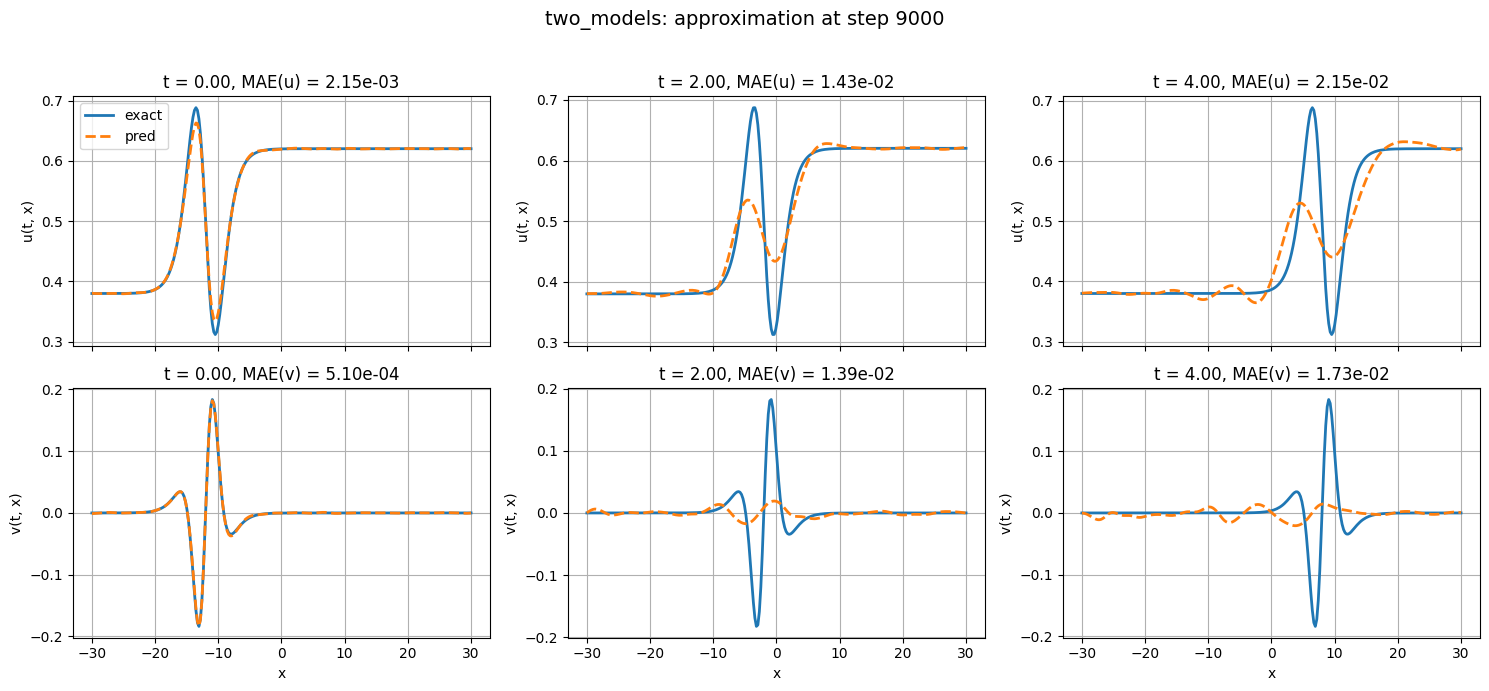

[two_models] step=09100 total=1.799330e-04
[two_models] step=09200 total=1.788951e-04
[two_models] step=09300 total=1.769540e-04
[two_models] step=09400 total=1.756206e-04
[two_models] step=09500 total=1.753517e-04
[two_models] step=09600 total=1.744410e-04
[two_models] step=09700 total=1.952843e-04
[two_models] step=09800 total=1.697100e-04
[two_models] step=09900 total=1.672547e-04
[two_models] step=10000 total=1.663735e-04


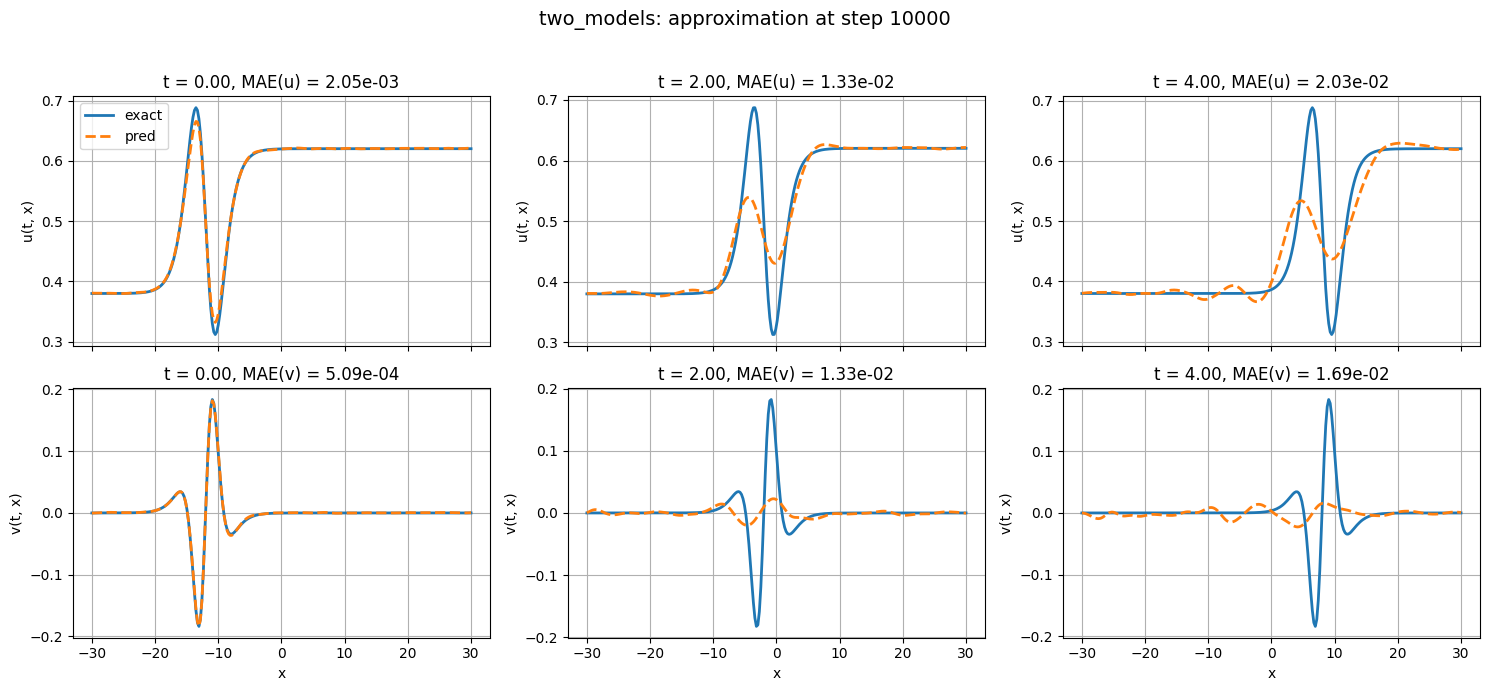

[two_models] step=10100 total=2.027032e-04
[two_models] step=10200 total=1.628896e-04
[two_models] step=10300 total=1.616591e-04
[two_models] step=10400 total=1.607567e-04
[two_models] step=10500 total=1.705901e-04
[two_models] step=10600 total=1.593702e-04
[two_models] step=10700 total=1.558969e-04
[two_models] step=10800 total=1.559335e-04
[two_models] step=10900 total=1.543715e-04
[two_models] step=11000 total=1.517675e-04


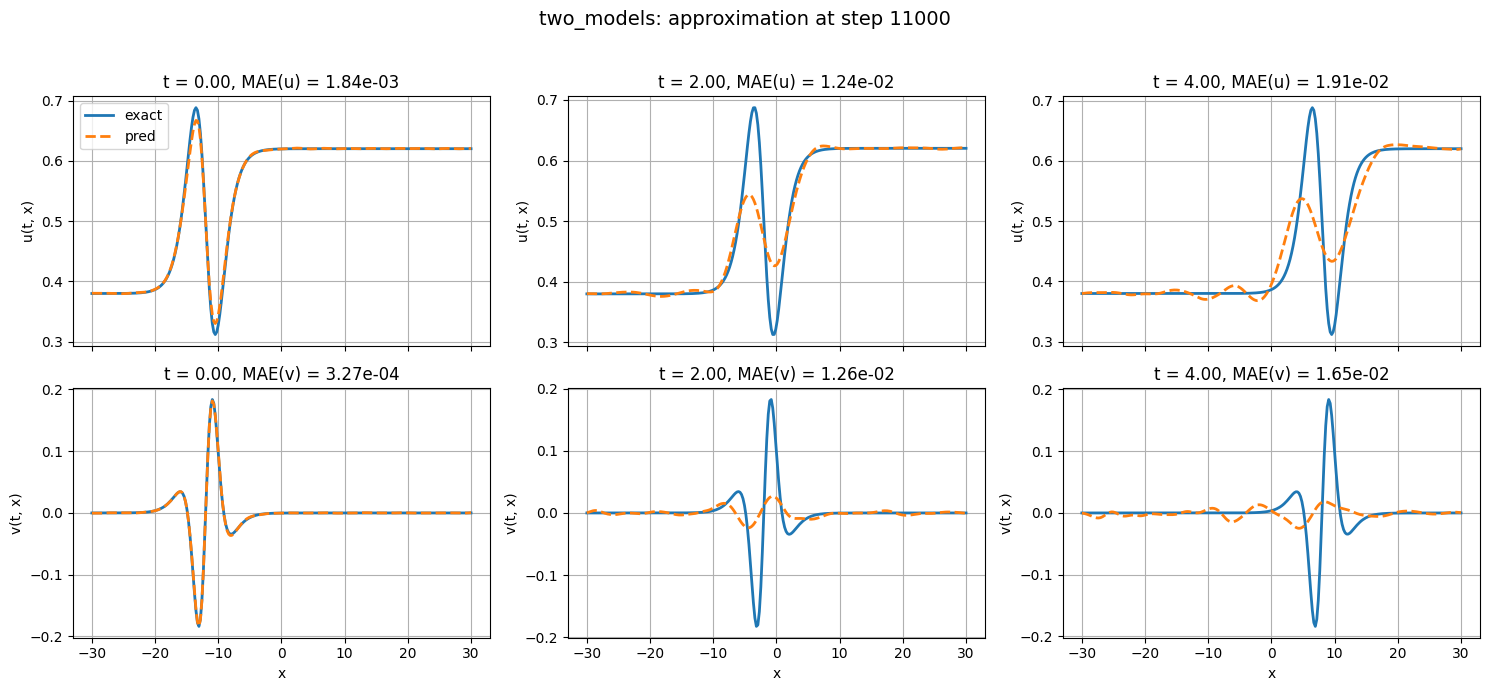

[two_models] step=11100 total=2.207899e-04
[two_models] step=11200 total=2.787704e-04
[two_models] step=11300 total=1.480235e-04
[two_models] step=11400 total=1.463307e-04
[two_models] step=11500 total=1.466491e-04
[two_models] step=11600 total=1.488350e-04
[two_models] step=11700 total=2.243896e-04
[two_models] step=11800 total=1.413806e-04
[two_models] step=11900 total=1.546915e-04
[two_models] step=12000 total=1.398004e-04


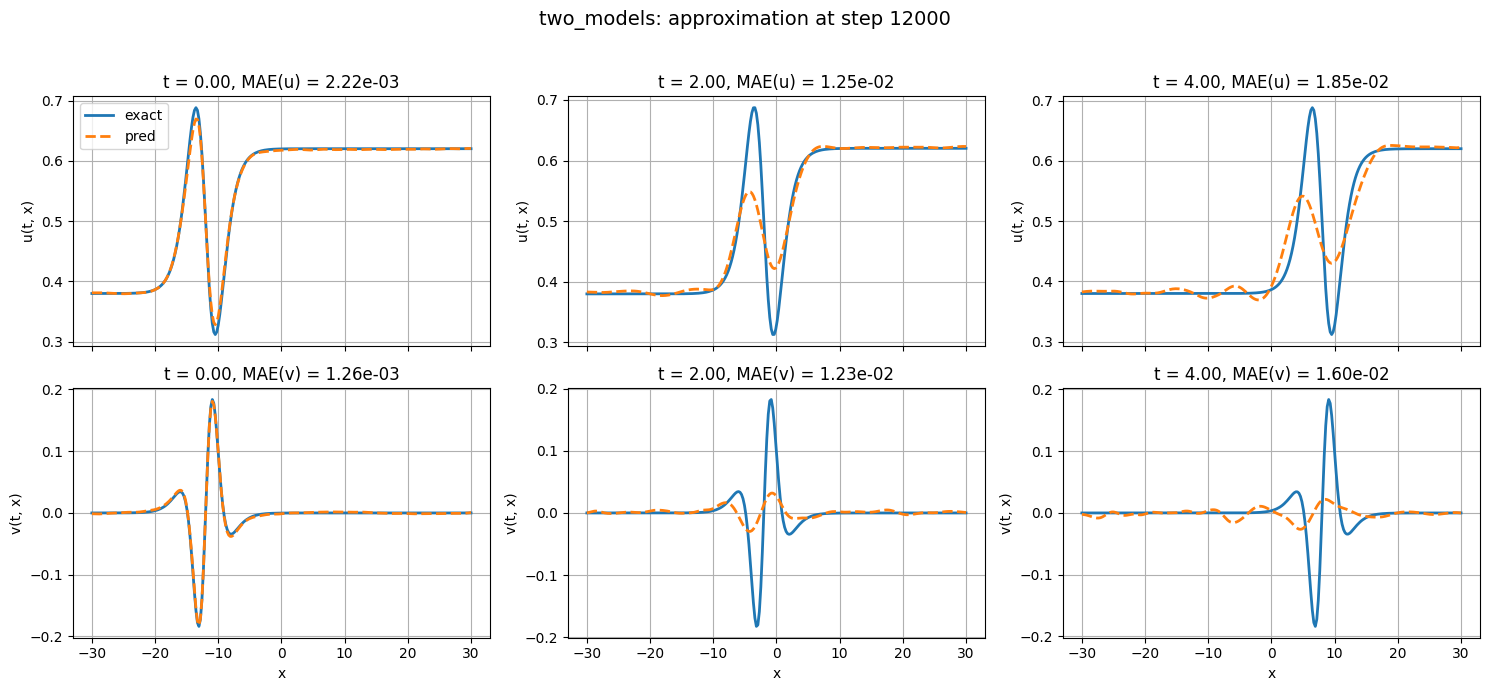

[two_models] step=12100 total=1.372755e-04
[two_models] step=12200 total=1.361559e-04
[two_models] step=12300 total=1.417621e-04
[two_models] step=12400 total=1.652182e-04
[two_models] step=12500 total=1.562948e-04
[two_models] step=12600 total=1.402609e-04
[two_models] step=12700 total=1.314779e-04
[two_models] step=12800 total=1.340795e-04
[two_models] step=12900 total=1.312201e-04
[two_models] step=13000 total=1.594162e-04


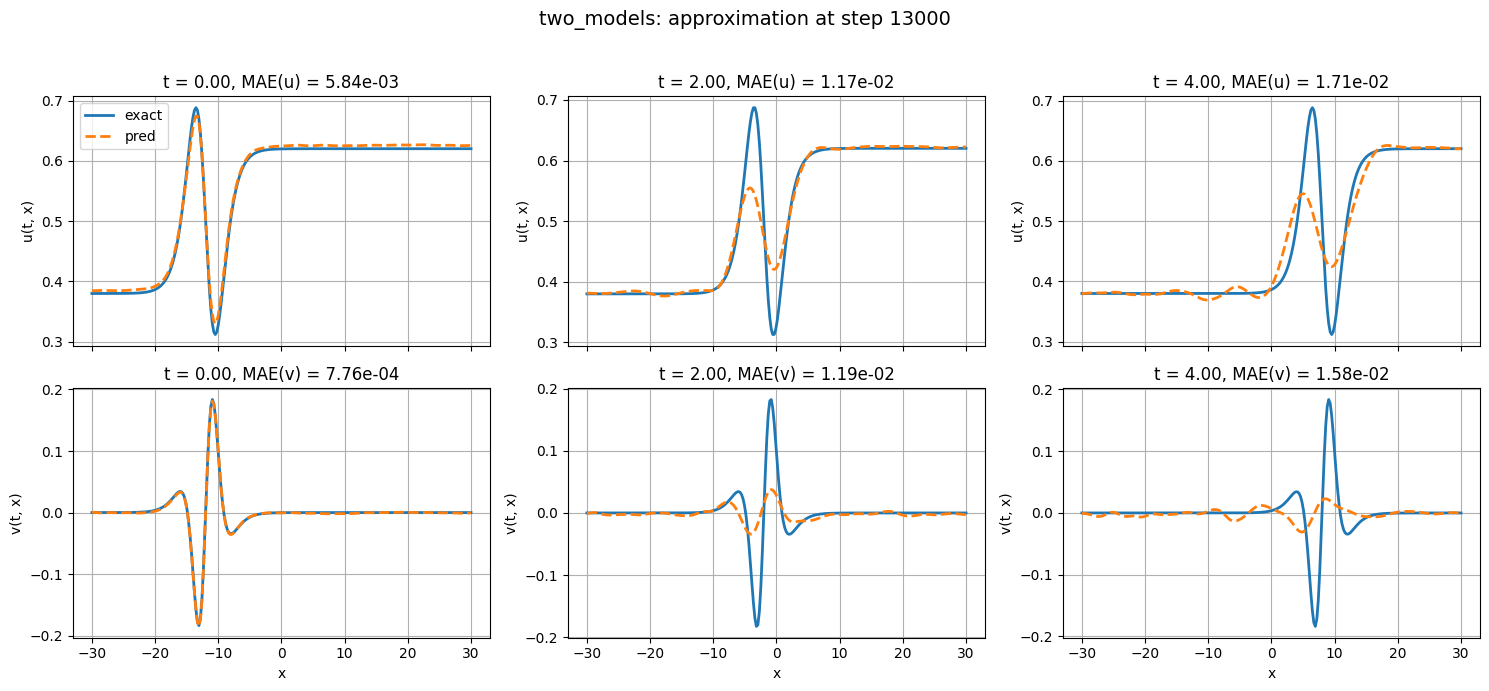

[two_models] elapsed: 11461.76 sec
[shared_trunk] training device: /CPU:0
[shared_trunk] step=00000 total=1.861548e+00


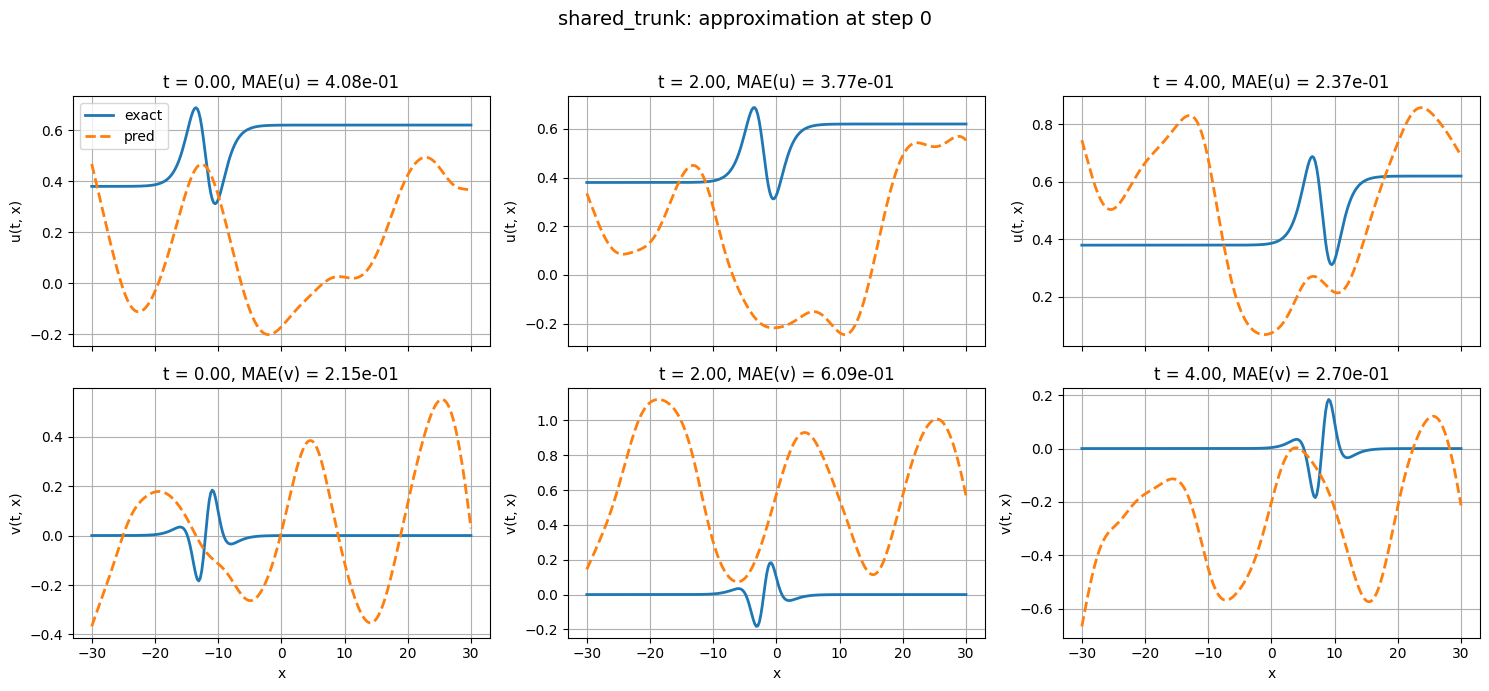

[shared_trunk] step=00100 total=2.297143e-02
[shared_trunk] step=00200 total=9.785761e-03
[shared_trunk] step=00300 total=6.547460e-03
[shared_trunk] step=00400 total=5.191380e-03
[shared_trunk] step=00500 total=4.460975e-03
[shared_trunk] step=00600 total=4.006253e-03
[shared_trunk] step=00700 total=3.693493e-03
[shared_trunk] step=00800 total=3.461578e-03
[shared_trunk] step=00900 total=3.279033e-03
[shared_trunk] step=01000 total=3.128320e-03


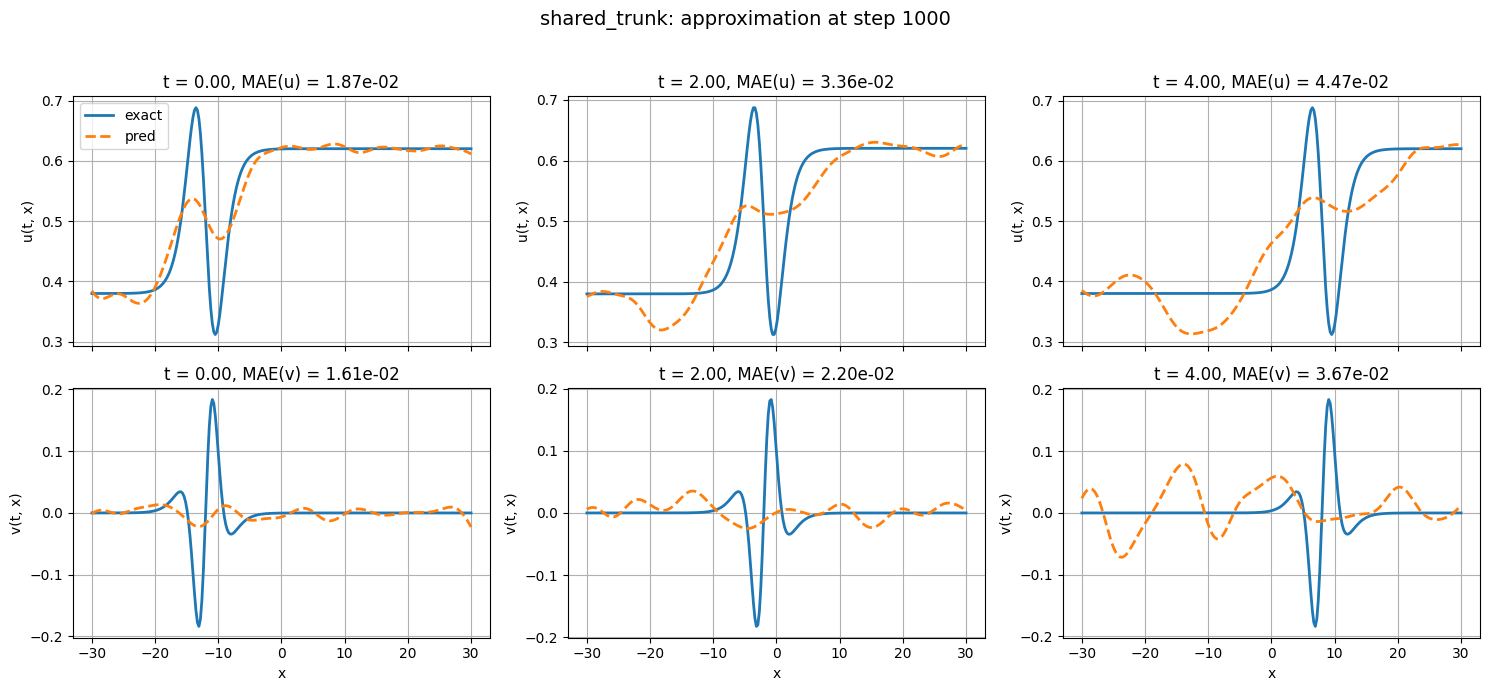

[shared_trunk] step=01100 total=2.999105e-03
[shared_trunk] step=01200 total=2.885004e-03
[shared_trunk] step=01300 total=2.781884e-03
[shared_trunk] step=01400 total=2.686950e-03
[shared_trunk] step=01500 total=2.598231e-03
[shared_trunk] step=01600 total=2.514298e-03
[shared_trunk] step=01700 total=2.434097e-03
[shared_trunk] step=01800 total=2.356849e-03
[shared_trunk] step=01900 total=2.281976e-03
[shared_trunk] step=02000 total=2.209052e-03


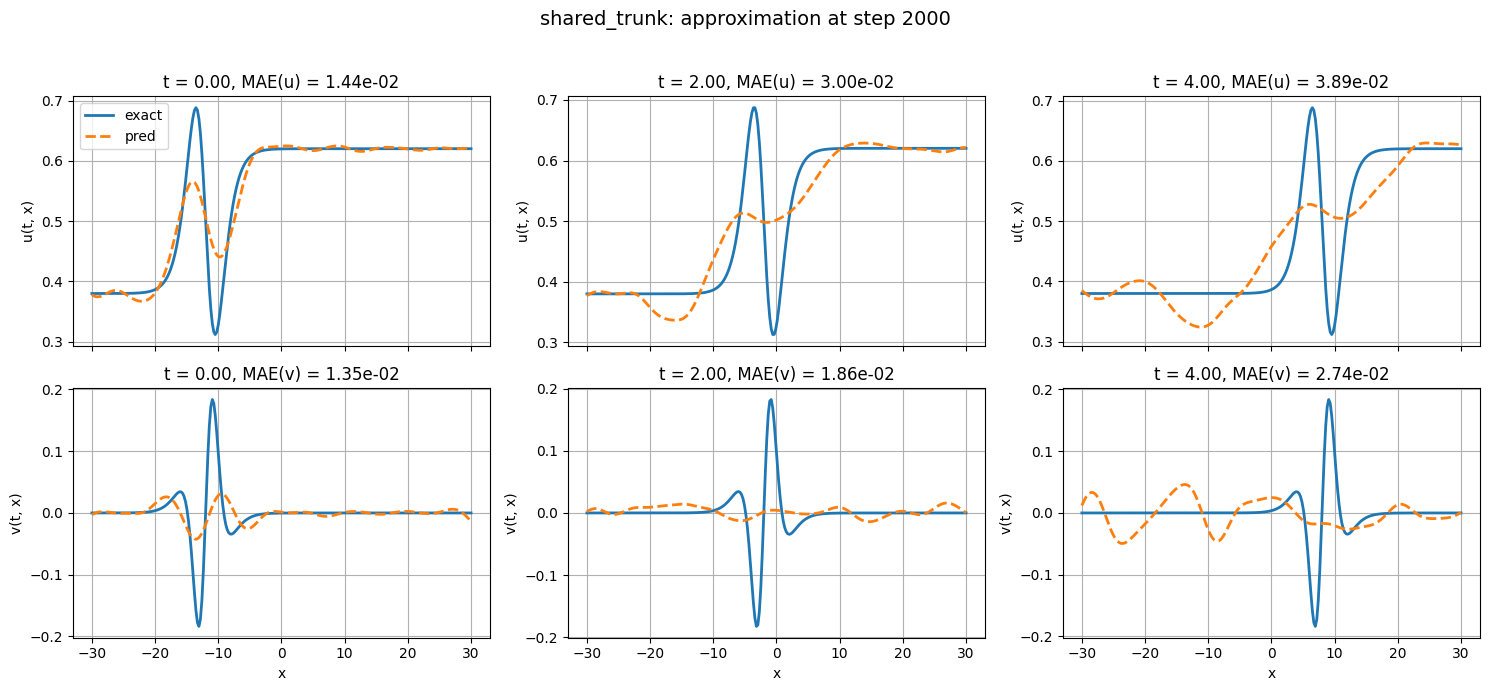

[shared_trunk] step=02100 total=2.137762e-03
[shared_trunk] step=02200 total=2.067863e-03
[shared_trunk] step=02300 total=1.999151e-03
[shared_trunk] step=02400 total=1.931429e-03
[shared_trunk] step=02500 total=1.864484e-03
[shared_trunk] step=02600 total=1.798078e-03
[shared_trunk] step=02700 total=1.731951e-03
[shared_trunk] step=02800 total=1.665844e-03
[shared_trunk] step=02900 total=1.599537e-03
[shared_trunk] step=03000 total=1.532872e-03


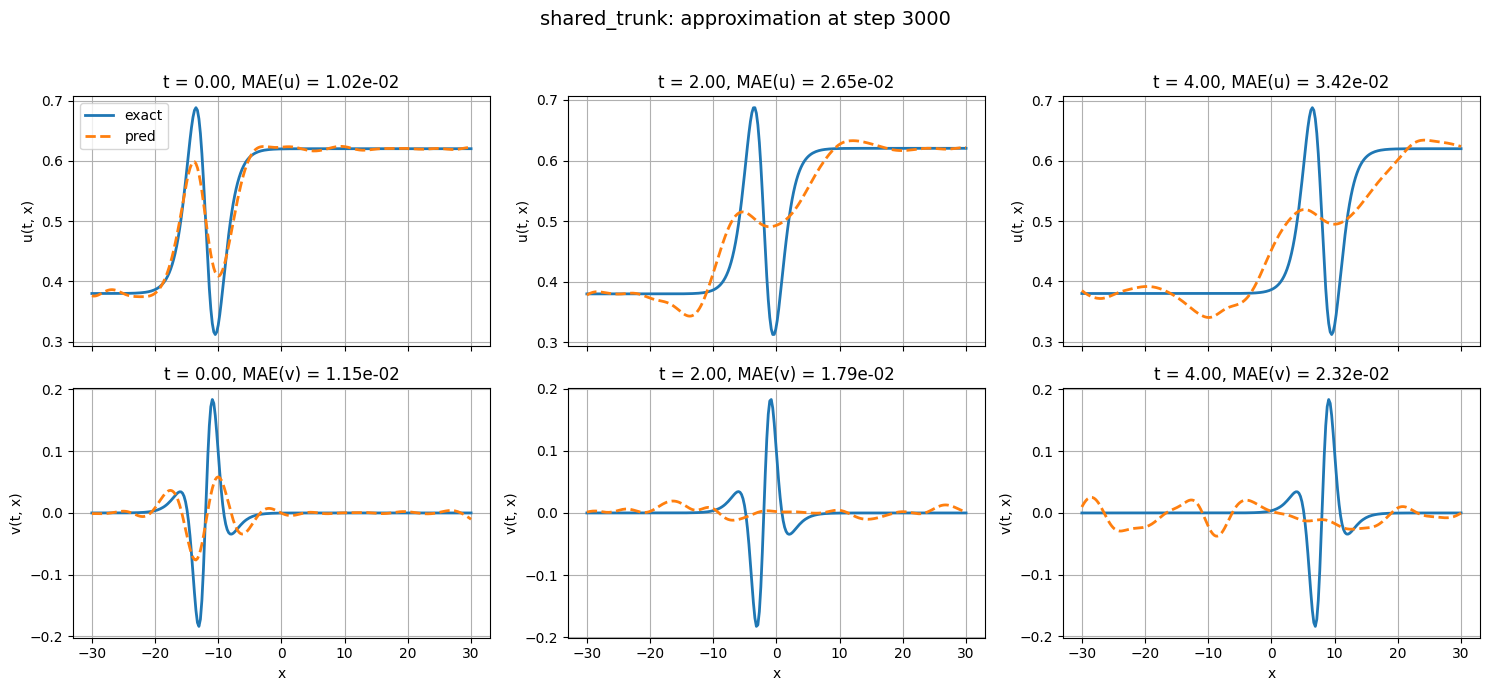

[shared_trunk] step=03100 total=1.465777e-03
[shared_trunk] step=03200 total=1.398263e-03
[shared_trunk] step=03300 total=1.330415e-03
[shared_trunk] step=03400 total=1.262395e-03
[shared_trunk] step=03500 total=1.194453e-03
[shared_trunk] step=03600 total=1.126951e-03
[shared_trunk] step=03700 total=1.060371e-03
[shared_trunk] step=03800 total=9.952939e-04
[shared_trunk] step=03900 total=9.323494e-04
[shared_trunk] step=04000 total=8.721495e-04


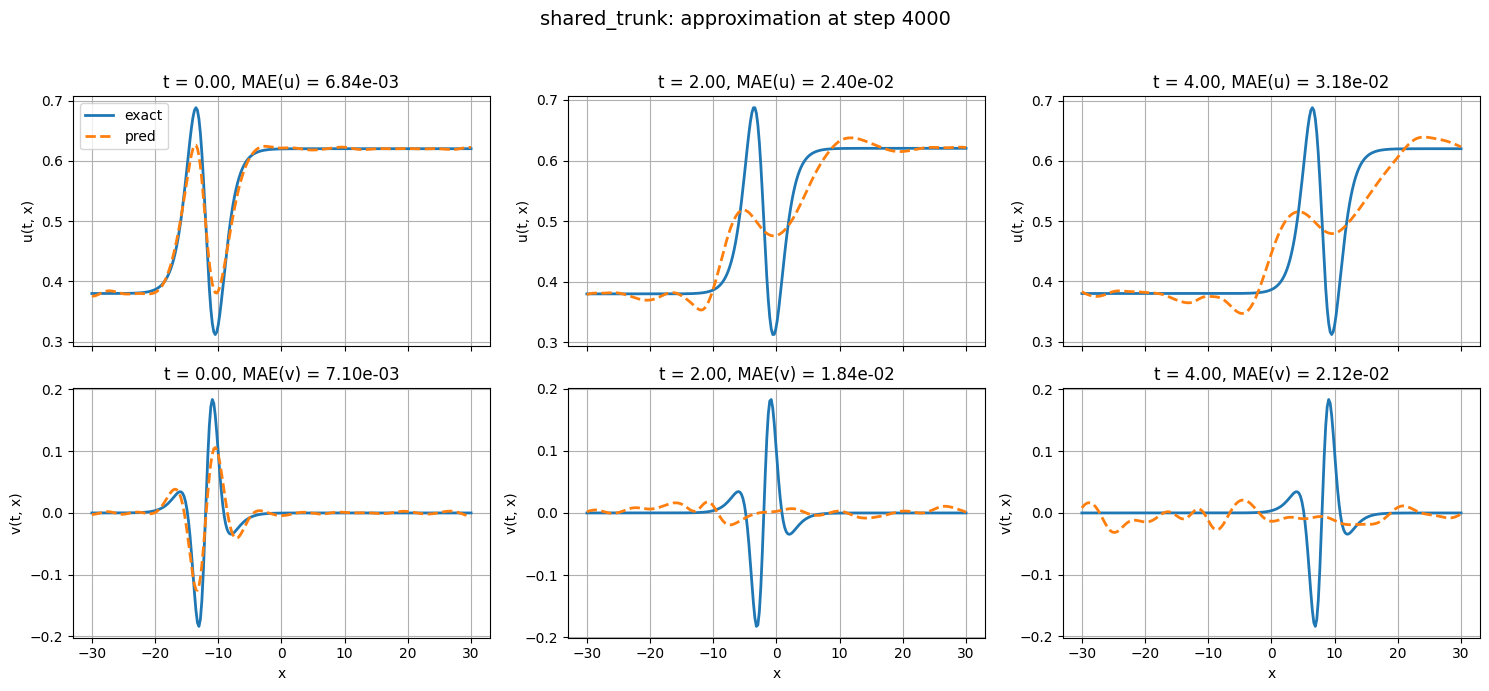

[shared_trunk] step=04100 total=8.152303e-04
[shared_trunk] step=04200 total=7.727826e-04
[shared_trunk] step=04300 total=7.185519e-04
[shared_trunk] step=04400 total=6.766762e-04
[shared_trunk] step=04500 total=6.381165e-04
[shared_trunk] step=04600 total=6.028161e-04
[shared_trunk] step=04700 total=6.055087e-04
[shared_trunk] step=04800 total=5.445339e-04
[shared_trunk] step=04900 total=5.197895e-04
[shared_trunk] step=05000 total=4.971509e-04


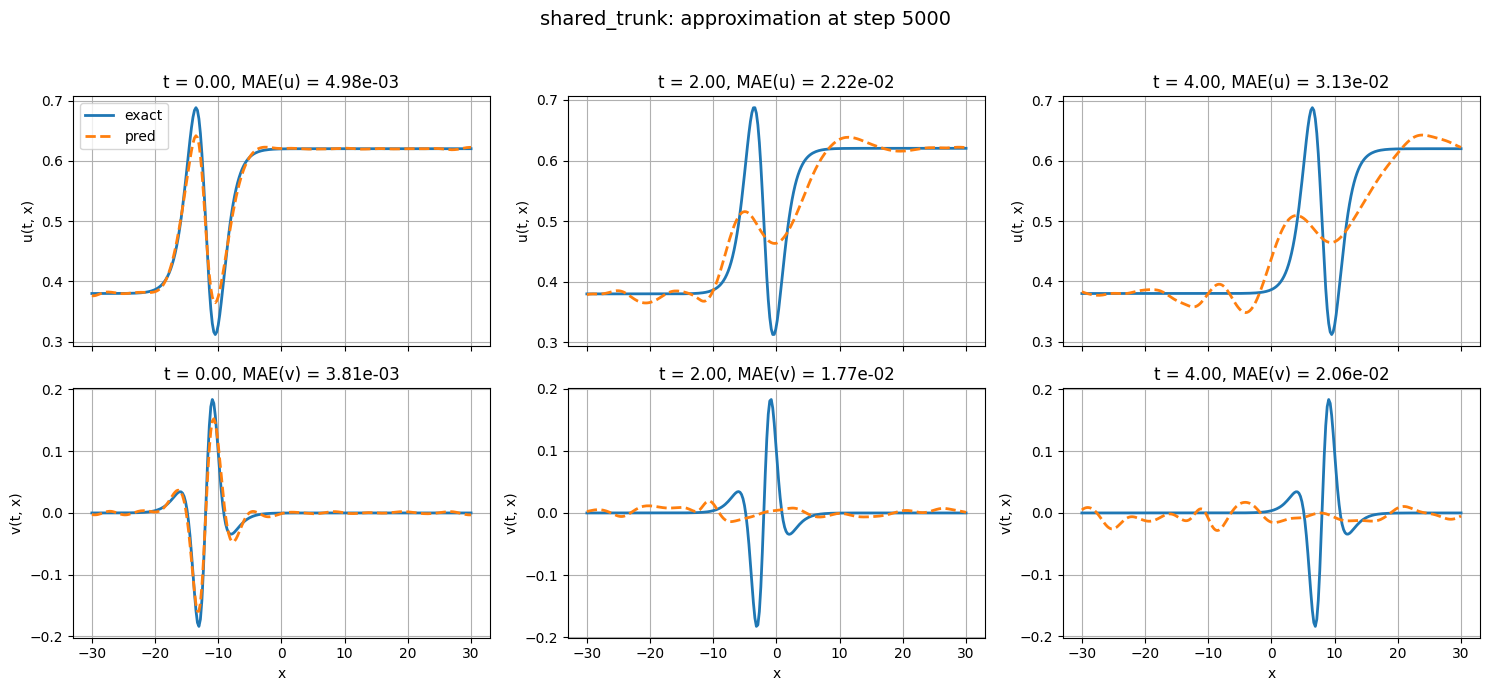

[shared_trunk] step=05100 total=4.764618e-04
[shared_trunk] step=05200 total=4.623020e-04
[shared_trunk] step=05300 total=4.424521e-04
[shared_trunk] step=05400 total=4.277111e-04
[shared_trunk] step=05500 total=4.140771e-04
[shared_trunk] step=05600 total=4.014496e-04
[shared_trunk] step=05700 total=3.906829e-04
[shared_trunk] step=05800 total=3.805399e-04
[shared_trunk] step=05900 total=3.710899e-04
[shared_trunk] step=06000 total=3.621756e-04


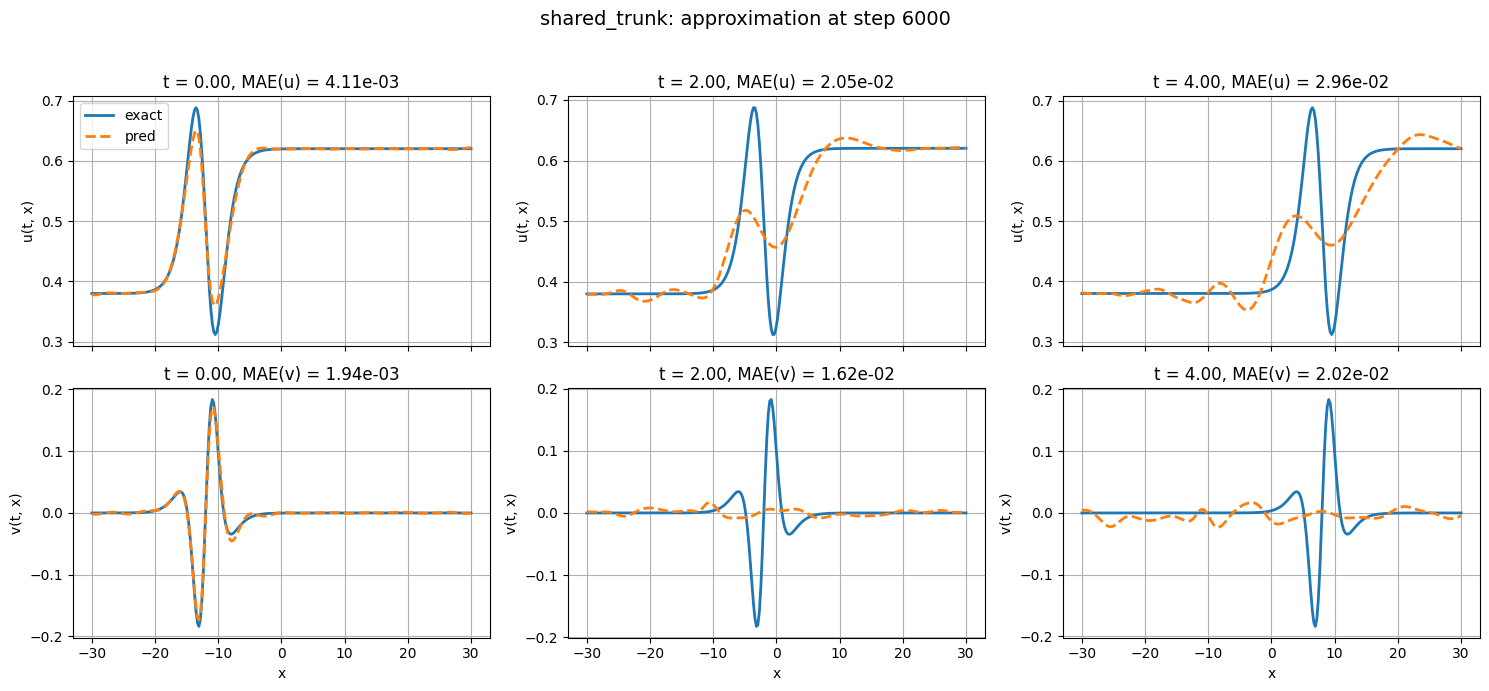

[shared_trunk] step=06100 total=3.576844e-04
[shared_trunk] step=06200 total=3.466435e-04
[shared_trunk] step=06300 total=3.397241e-04
[shared_trunk] step=06400 total=3.331116e-04
[shared_trunk] step=06500 total=3.267650e-04
[shared_trunk] step=06600 total=5.051680e-04
[shared_trunk] step=06700 total=3.156581e-04
[shared_trunk] step=06800 total=3.106312e-04
[shared_trunk] step=06900 total=3.057398e-04
[shared_trunk] step=07000 total=3.009630e-04


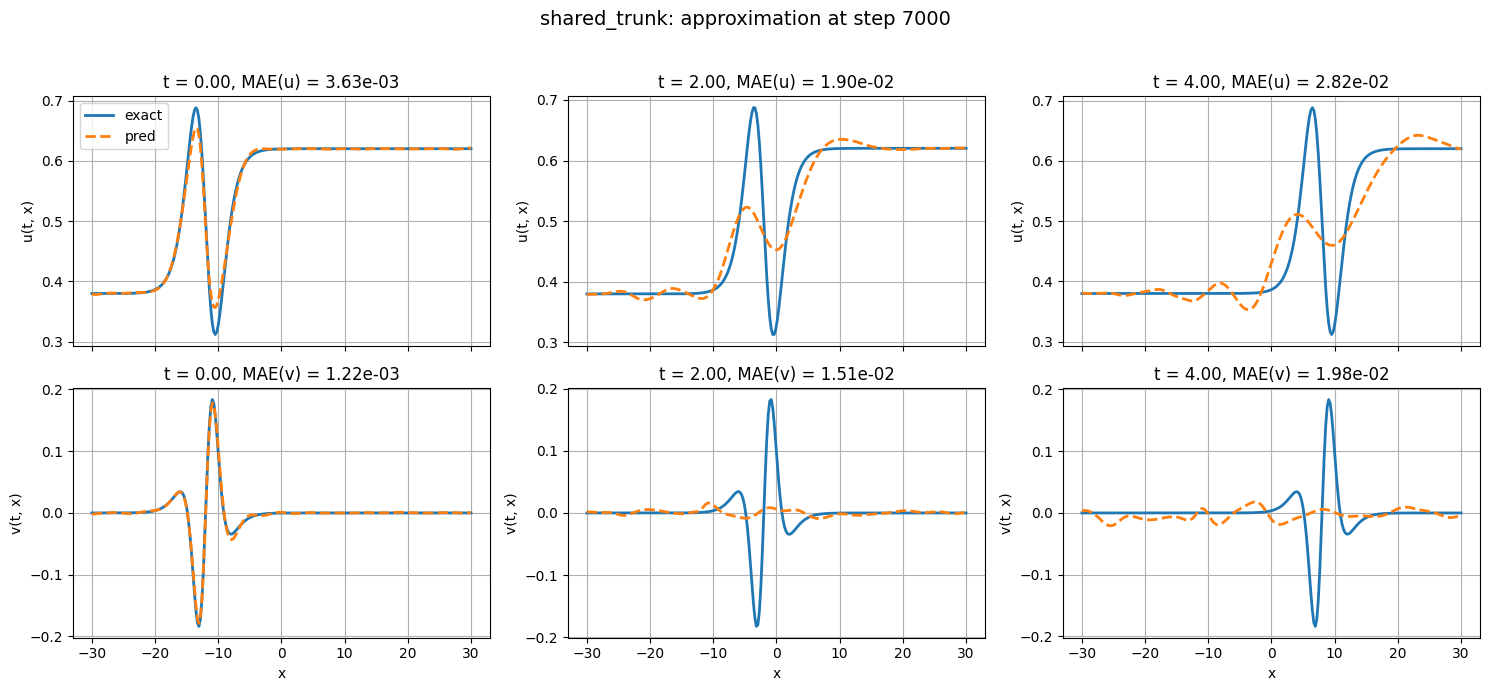

[shared_trunk] step=07100 total=3.450859e-04
[shared_trunk] step=07200 total=2.924667e-04
[shared_trunk] step=07300 total=2.884853e-04
[shared_trunk] step=07400 total=2.845527e-04
[shared_trunk] step=07500 total=2.806579e-04
[shared_trunk] step=07600 total=2.992083e-04
[shared_trunk] step=07700 total=2.737737e-04
[shared_trunk] step=07800 total=2.705429e-04
[shared_trunk] step=07900 total=2.673155e-04
[shared_trunk] step=08000 total=2.736202e-04


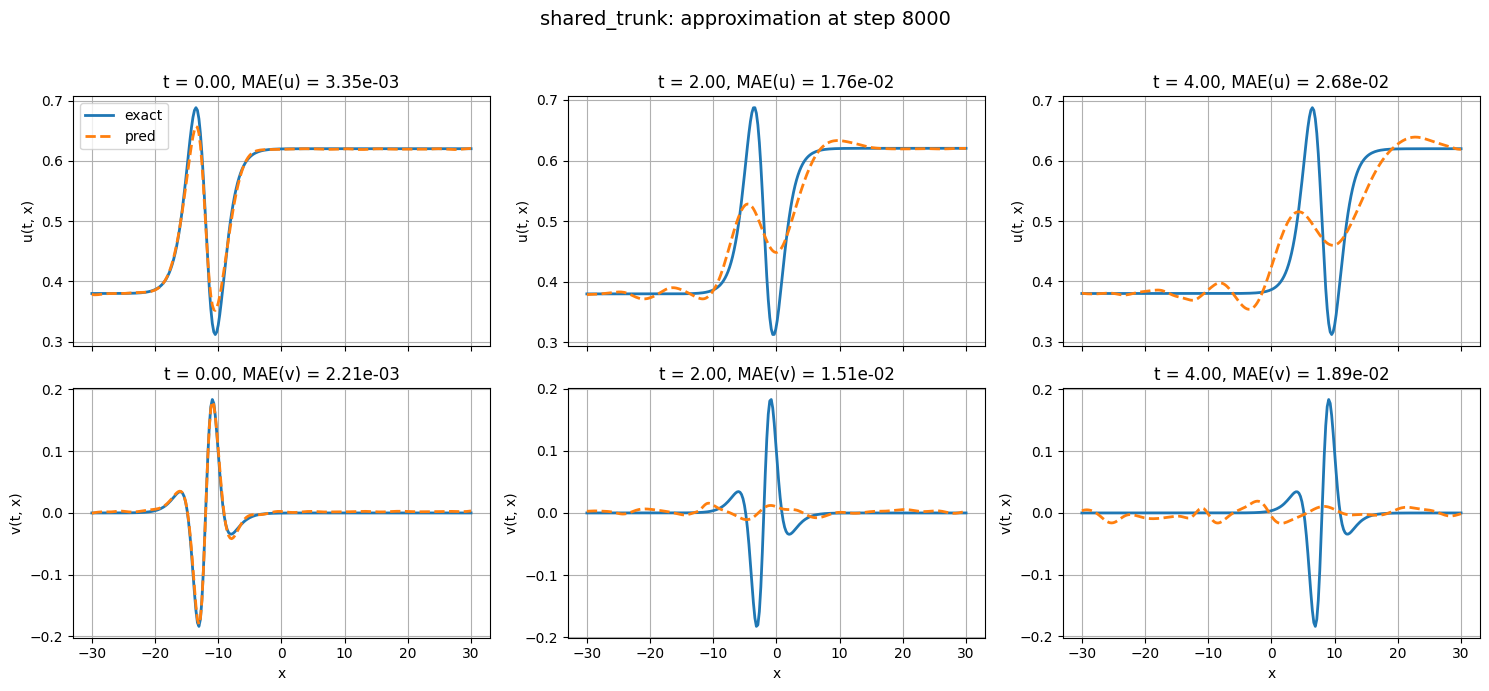

[shared_trunk] step=08100 total=2.612468e-04
[shared_trunk] step=08200 total=2.623096e-04
[shared_trunk] step=08300 total=2.554389e-04
[shared_trunk] step=08400 total=5.867998e-04
[shared_trunk] step=08500 total=2.499023e-04
[shared_trunk] step=08600 total=2.542779e-04
[shared_trunk] step=08700 total=3.062591e-04
[shared_trunk] step=08800 total=2.420611e-04
[shared_trunk] step=08900 total=2.396910e-04
[shared_trunk] step=09000 total=2.371851e-04


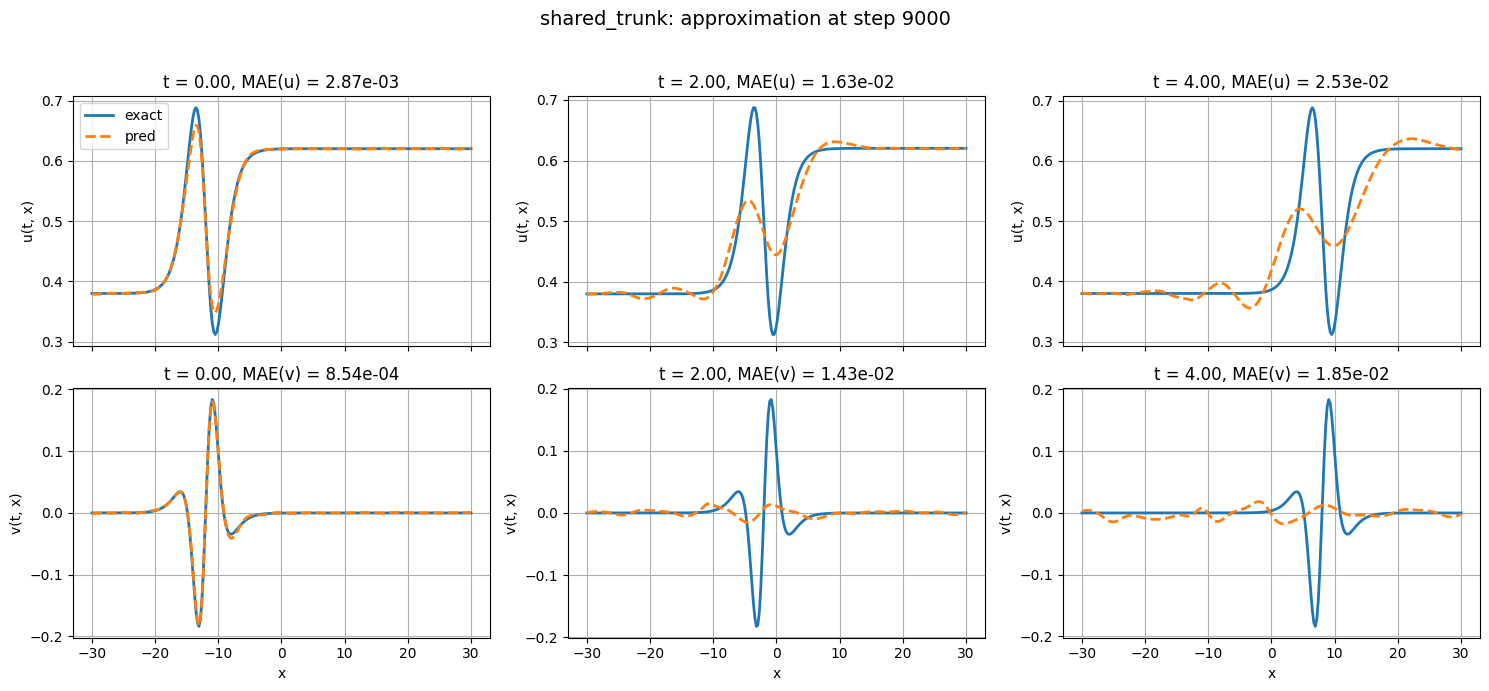

[shared_trunk] step=09100 total=2.366300e-04
[shared_trunk] step=09200 total=2.326058e-04
[shared_trunk] step=09300 total=2.381226e-04
[shared_trunk] step=09400 total=2.282590e-04
[shared_trunk] step=09500 total=8.026865e-04
[shared_trunk] step=09600 total=2.240314e-04
[shared_trunk] step=09700 total=2.218969e-04
[shared_trunk] step=09800 total=2.946707e-04
[shared_trunk] step=09900 total=2.200530e-04
[shared_trunk] step=10000 total=2.159136e-04


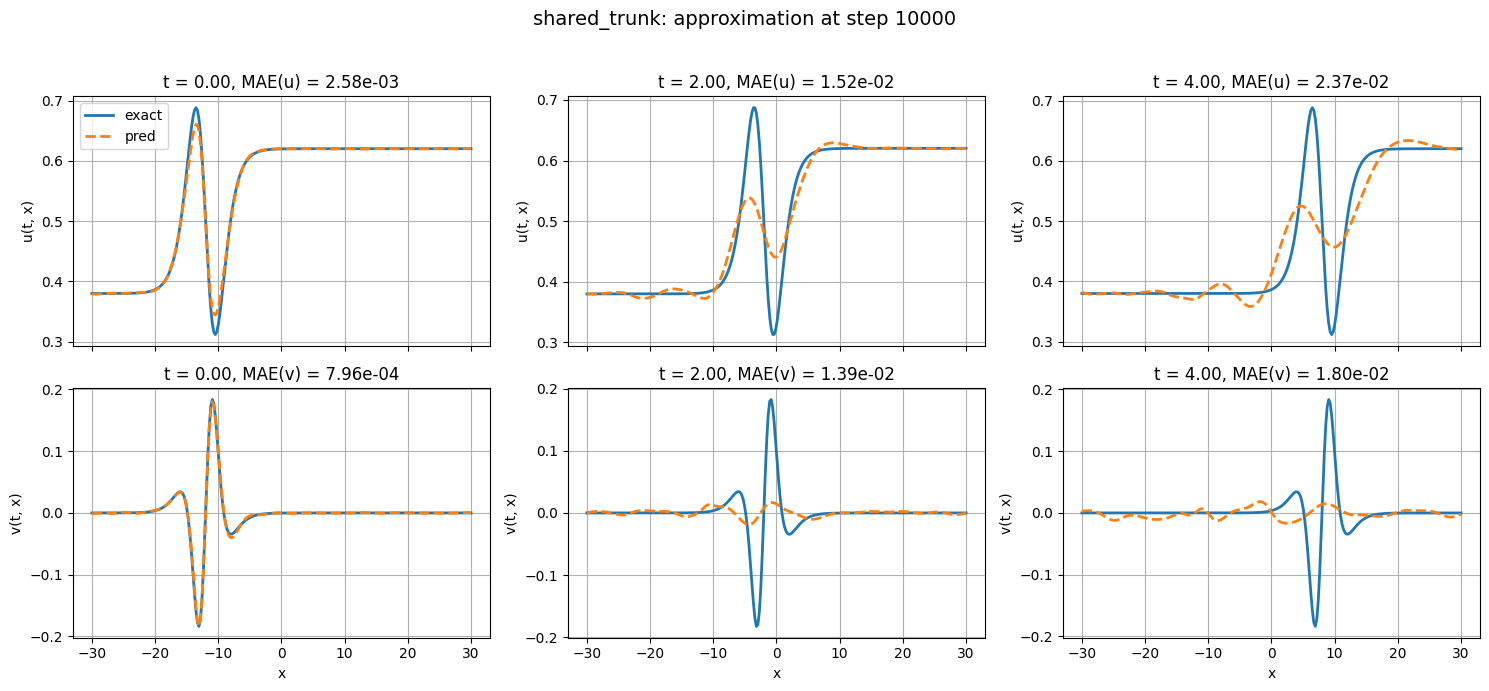

[shared_trunk] step=10100 total=2.166677e-04
[shared_trunk] step=10200 total=2.171098e-04
[shared_trunk] step=10300 total=2.100705e-04
[shared_trunk] step=10400 total=2.082503e-04
[shared_trunk] step=10500 total=2.064681e-04
[shared_trunk] step=10600 total=2.045330e-04
[shared_trunk] step=10700 total=2.049319e-04
[shared_trunk] step=10800 total=2.037208e-04
[shared_trunk] step=10900 total=1.999455e-04
[shared_trunk] step=11000 total=1.981330e-04


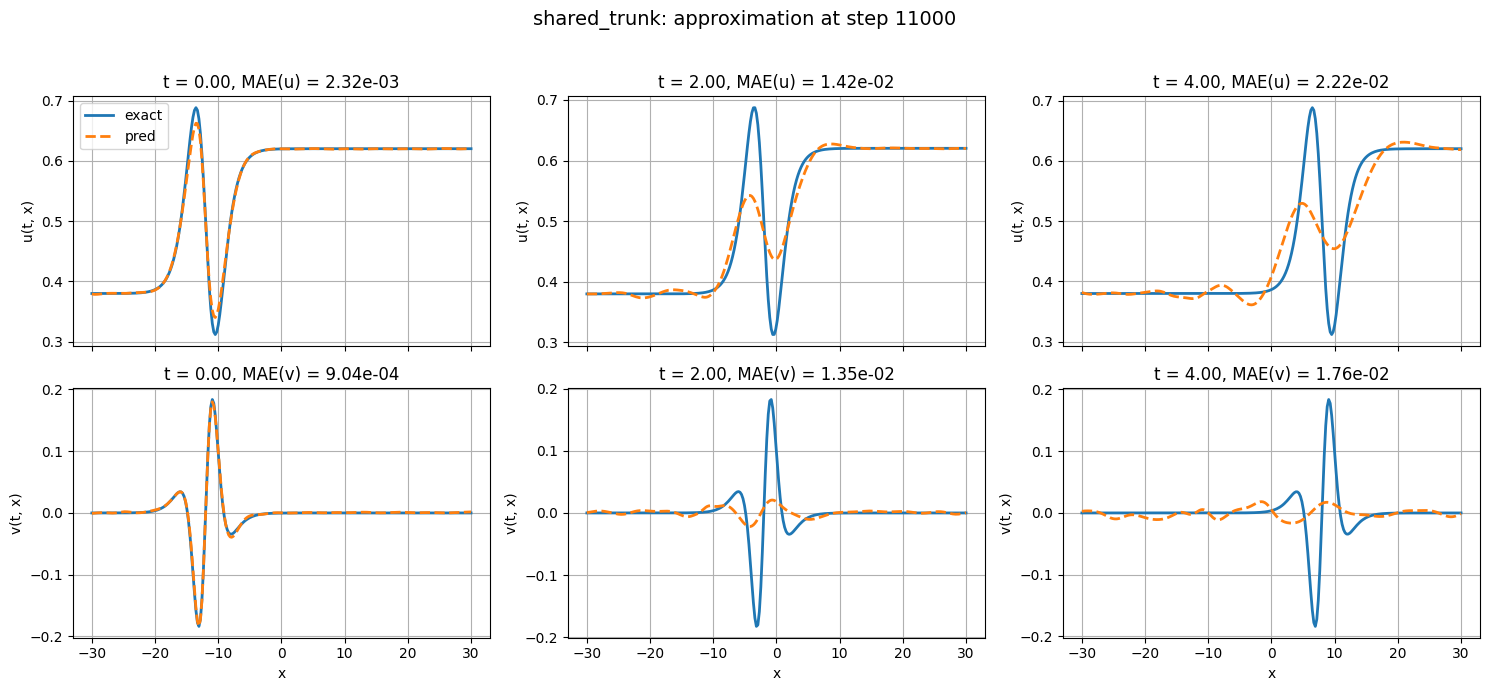

[shared_trunk] step=11100 total=1.957488e-04
[shared_trunk] step=11200 total=2.020525e-04
[shared_trunk] step=11300 total=1.923175e-04
[shared_trunk] step=11400 total=1.906683e-04
[shared_trunk] step=11500 total=1.924089e-04
[shared_trunk] step=11600 total=2.422662e-04
[shared_trunk] step=11700 total=1.949626e-04
[shared_trunk] step=11800 total=2.399619e-04
[shared_trunk] step=11900 total=1.825536e-04
[shared_trunk] step=12000 total=1.808948e-04


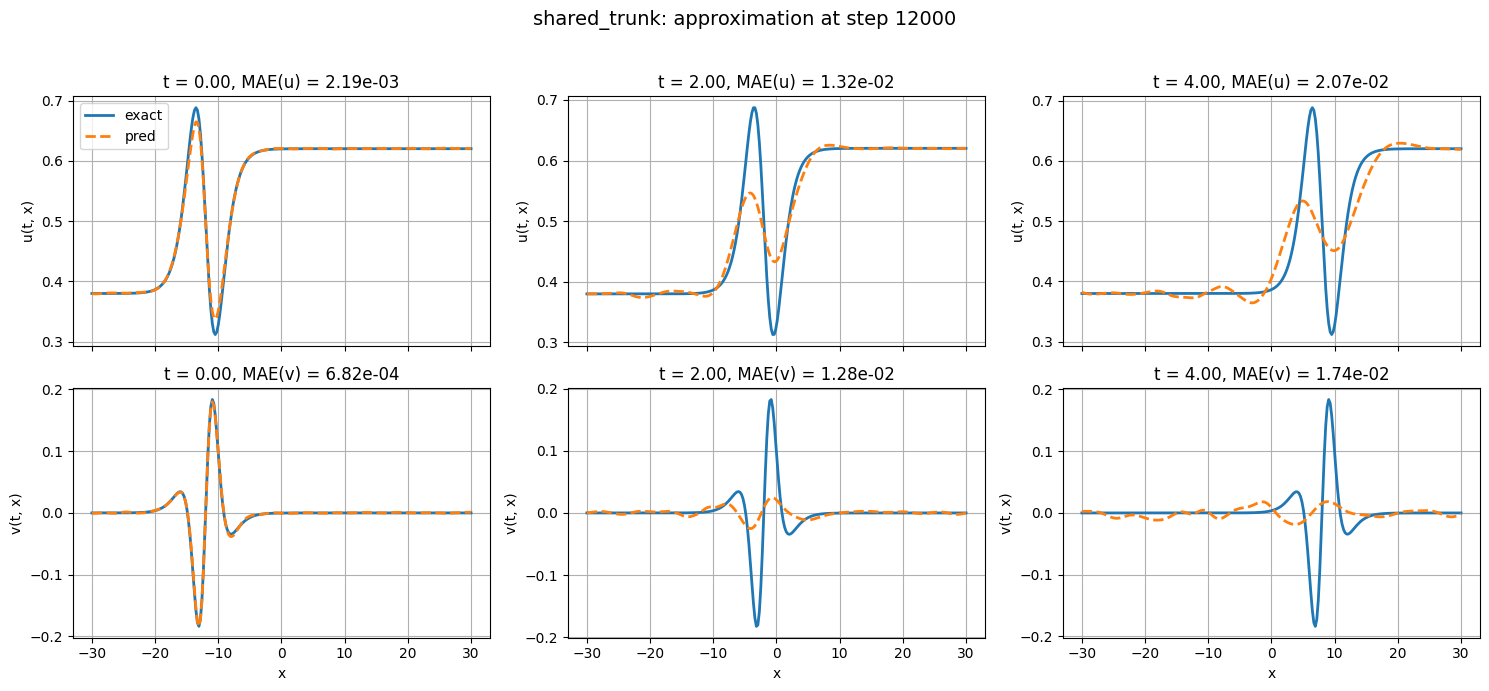

[shared_trunk] step=12100 total=2.772371e-04
[shared_trunk] step=12200 total=1.827579e-04
[shared_trunk] step=12300 total=1.788444e-04
[shared_trunk] step=12400 total=2.096772e-04
[shared_trunk] step=12500 total=1.985707e-04
[shared_trunk] step=12600 total=1.791945e-04
[shared_trunk] step=12700 total=1.717748e-04
[shared_trunk] step=12800 total=1.684975e-04
[shared_trunk] step=12900 total=1.668667e-04
[shared_trunk] step=13000 total=1.655856e-04


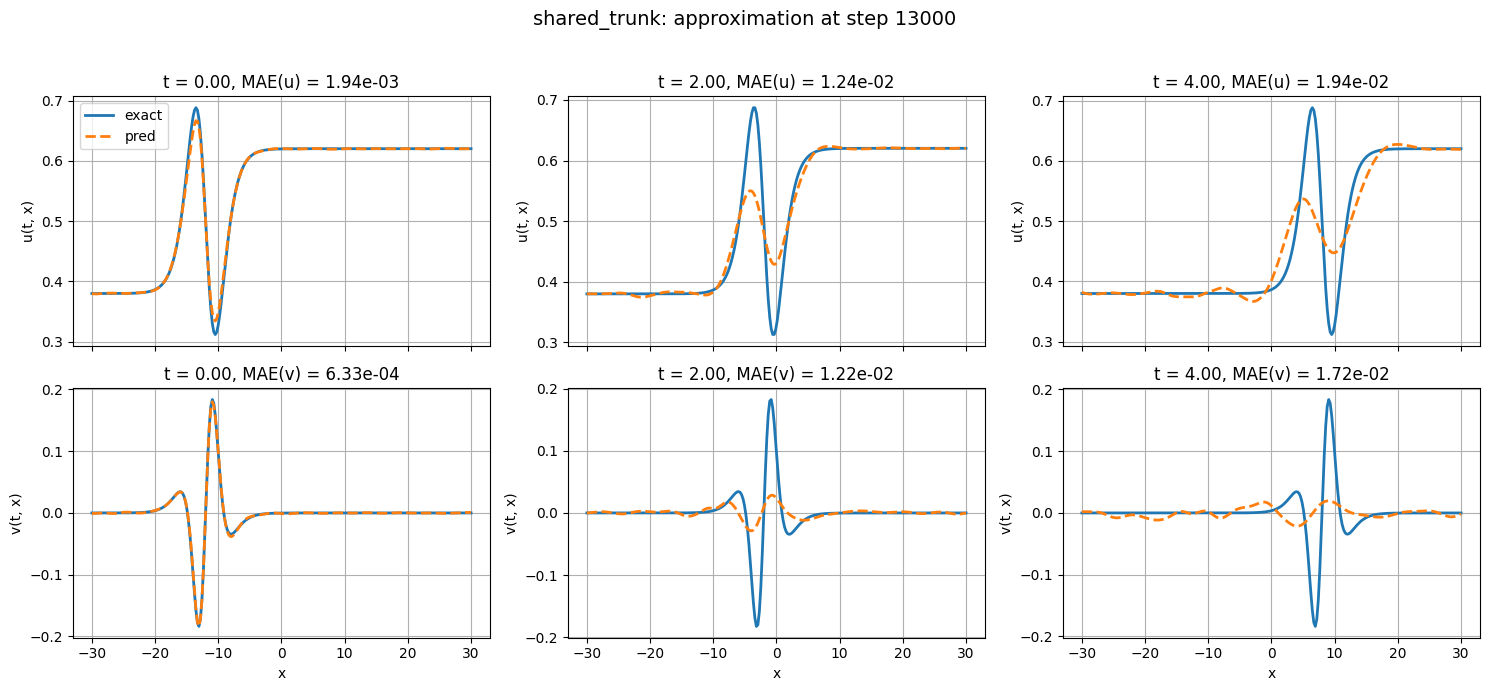

[shared_trunk] elapsed: 10599.59 sec


In [ ]:
with tf.device(TRAINING_DEVICE):
    history_two_output = run_training(two_output_model, two_output_optim, 'two_output', num_steps=NUM_STEPS, print_every=PRINT_EVERY, plot_every=PLOT_EVERY)
    history_two_models = run_training(two_models, two_models_optim, 'two_models', num_steps=NUM_STEPS, print_every=PRINT_EVERY, plot_every=PLOT_EVERY)
    history_shared_trunk = run_training(shared_trunk_model, shared_trunk_optim, 'shared_trunk', num_steps=NUM_STEPS, print_every=PRINT_EVERY, plot_every=PLOT_EVERY)


## 15. Сравнение графиков потерь

In [ ]:
def load_history_from_notebook(nb_path='start.ipynb'):
    nb_path = Path(nb_path)
    with nb_path.open('r', encoding='utf-8') as f:
        nb = json.load(f)

    pattern = re.compile(
        r"It\s+(\d+):\s+total=([0-9.eE+-]+),\s+phi_r=([0-9.eE+-]+),\s+phi_b=([0-9.eE+-]+),\s+phi_0=([0-9.eE+-]+)"
    )

    history = {
        'step': [],
        'total': [],
        'phi_r': [],
        'phi_b': [],
        'phi_0': [],
    }

    for cell in nb.get('cells', []):
        for output in cell.get('outputs', []):
            if output.get('output_type') != 'stream':
                continue

            text = output.get('text', '')
            if isinstance(text, list):
                text = ''.join(text)

            for match in pattern.finditer(text):
                history['step'].append(int(match.group(1)))
                history['total'].append(float(match.group(2)))
                history['phi_r'].append(float(match.group(3)))
                history['phi_b'].append(float(match.group(4)))
                history['phi_0'].append(float(match.group(5)))

    if not history['step']:
        raise ValueError(f'?? ??????? ??????? history ?? {nb_path}')

    return history


def plot_loss_curves_like_start(history, label):
    steps = np.array(history['step'])
    eps = 1e-12

    plt.figure(figsize=(8, 4))
    plt.semilogy(steps, np.array(history['total']) + eps, lw=1.4, label='total loss')
    plt.xlabel('iterations')
    plt.ylabel('loss (log scale)')
    plt.title(f'{label}: total loss')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.semilogy(steps, np.array(history['phi_r']) + eps, label='L_r (PDE)')
    plt.semilogy(steps, np.array(history['phi_0']) + eps, label='L_0 (IC)')
    plt.semilogy(steps, np.array(history['phi_b']) + eps, label='L_b (exact BC)')
    plt.xlabel('iterations')
    plt.ylabel('loss (log scale)')
    plt.title(f'{label}: loss components')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_histories(histories, stage1_history=None, stage1_label='stage1'):
    plt.figure(figsize=(9, 4))

    if stage1_history is not None:
        plt.semilogy(stage1_history['step'], stage1_history['total'], '--', lw=2, label=stage1_label)

    for label, history in histories.items():
        plt.semilogy(history['step'], history['total'], label=label)

    plt.xlabel('iteration')
    plt.ylabel('total loss')
    plt.title('Сравнение сходимости: этап 1 и три подхода этапа 2')
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_history(history, label):
    total = np.array(history['total'])
    steps = np.array(history['step'])
    best_idx = int(np.argmin(total))

    return {
        'label': label,
        'best_step': int(steps[best_idx]),
        'best_total': float(total[best_idx]),
        'final_total': float(total[-1]),
    }


def print_history_summary(histories, stage1_history=None, stage1_label='stage1'):
    rows = []
    if stage1_history is not None:
        rows.append(summarize_history(stage1_history, stage1_label))

    for label, history in histories.items():
        rows.append(summarize_history(history, label))

    for row in rows:
        print(
            f"{row['label']}: best_step={row['best_step']}, "
            f"best_total={row['best_total']:.6e}, final_total={row['final_total']:.6e}"
        )


# # ?????? ?????????????:
# stage1_history = load_history_from_notebook('start.ipynb')
# plot_histories({
#     'two_output': history_two_output,
#     'two_models': history_two_models,
#     'shared_trunk': history_shared_trunk,
# }, stage1_history=stage1_history, stage1_label='stage1_start')
# print_history_summary({
#     'two_output': history_two_output,
#     'two_models': history_two_models,
#     'shared_trunk': history_shared_trunk,
# }, stage1_history=stage1_history, stage1_label='stage1_start')

SAVE_WEIGHT_MATRICES = False
WEIGHT_MATRICES_DIR = Path('saved_weight_matrices')


def ensure_model_is_built(model):
    dummy_X = tf.zeros((1, 2), dtype=tf.dtypes.as_dtype(DTYPE))
    model(dummy_X, training=False)
    return model


def iter_weight_tensors(model, model_label):
    ensure_model_is_built(model)
    for layer in model.layers:
        arrays = layer.get_weights()
        if not arrays:
            continue

        param_names = []
        for idx, weight_var in enumerate(layer.weights[:len(arrays)]):
            param_names.append(weight_var.name.split(':')[0].split('/')[-1])

        for idx, array in enumerate(arrays):
            param_name = param_names[idx] if idx < len(param_names) else f'param_{idx}'
            yield {
                'name': f'{model_label}/{layer.name}/{param_name}',
                'array': np.array(array),
            }


def collect_weight_tensors(model_like, variant_name):
    if variant_name == 'two_models':
        model_map = {
            'model_u': model_like['u'],
            'model_v': model_like['v'],
        }
    else:
        model_map = {variant_name: model_like}

    tensors = []
    for model_label, model in model_map.items():
        tensors.extend(iter_weight_tensors(model, model_label))
    return tensors


def sanitize_weight_name(name):
    return re.sub(r'[^0-9A-Za-z_.-]+', '_', name)


def save_weight_matrices(model_registry, output_dir=WEIGHT_MATRICES_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    manifests = {}

    for variant_name, model_like in model_registry.items():
        variant_dir = output_dir / variant_name
        variant_dir.mkdir(parents=True, exist_ok=True)

        entries = []
        for idx, tensor in enumerate(collect_weight_tensors(model_like, variant_name)):
            file_path = variant_dir / f"{idx:02d}_{sanitize_weight_name(tensor['name'])}.npy"
            np.save(file_path, tensor['array'])
            entries.append({
                'name': tensor['name'],
                'shape': list(tensor['array'].shape),
                'path': str(file_path),
            })

        manifest_path = variant_dir / 'manifest.json'
        with manifest_path.open('w', encoding='utf-8') as fh:
            json.dump(entries, fh, ensure_ascii=False, indent=2)

        manifests[variant_name] = entries
        print(f'[{variant_name}] saved {len(entries)} weight tensors -> {variant_dir}')

    return manifests


def print_saved_weight_matrices(manifests, max_items_per_variant=None):
    old_options = np.get_printoptions()
    np.set_printoptions(precision=6, suppress=True, linewidth=120, threshold=200)
    try:
        for variant_name, entries in manifests.items():
            print(f'\n===== {variant_name} =====')
            visible_entries = entries if max_items_per_variant is None else entries[:max_items_per_variant]
            for entry in visible_entries:
                array = np.load(entry['path'])
                print(f"{entry['name']} shape={tuple(entry['shape'])}")
                print(array)
                print()

            if max_items_per_variant is not None and len(entries) > max_items_per_variant:
                hidden_count = len(entries) - max_items_per_variant
                print(f'... skipped {hidden_count} tensors for {variant_name}')
    finally:
        np.set_printoptions(**old_options)


## 16. Сравнение с этапом 1

По ТЗ нужно сравнить график сходимости этапа 2 с результатами этапа 1.


1. функция `load_history_from_notebook('start.ipynb')` читает сохраненный лог обучения из ноутбука первого этапа;
2. `plot_histories(..., stage1_history=...)` накладывает кривую этапа 1 на графики этапа 2;
3. `print_history_summary(...)` печатает краткую сводку по лучшему и финальному лоссу.

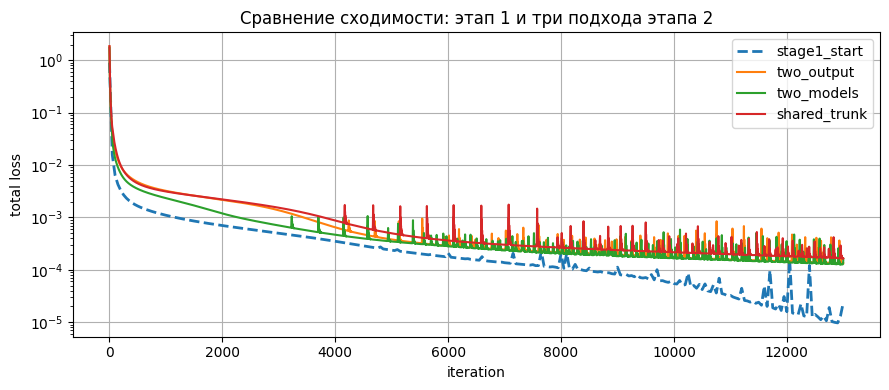

stage1_start: best_step=12900, best_total=9.691403e-06, final_total=2.382773e-05
two_output: best_step=13000, best_total=1.332877e-04, final_total=1.332877e-04
two_models: best_step=12976, best_total=1.265071e-04, final_total=1.594162e-04
shared_trunk: best_step=12990, best_total=1.654307e-04, final_total=1.655856e-04


In [ ]:


stage1_history = load_history_from_notebook('start.ipynb')
plot_histories({
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}, stage1_history=stage1_history, stage1_label='stage1_start')
print_history_summary({
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}, stage1_history=stage1_history, stage1_label='stage1_start')


## 17. Матрицы весов

Сохраняем матрицы весов каждой обученной модели в `.npy` только если включён флаг `SAVE_WEIGHT_MATRICES`.


In [ ]:
required_models = ['two_output_model', 'two_models', 'shared_trunk_model']
missing_models = [name for name in required_models if name not in globals()]
if missing_models:
    raise RuntimeError(f'Run the model initialization/training cells first. Missing: {missing_models}')

trained_models = {
    'two_output': two_output_model,
    'two_models': two_models,
    'shared_trunk': shared_trunk_model,
}

if SAVE_WEIGHT_MATRICES:
    weight_manifests = save_weight_matrices(trained_models)
    print_saved_weight_matrices(weight_manifests)
else:
    print('SAVE_WEIGHT_MATRICES = False, skipping weight export.')


SAVE_WEIGHT_MATRICES = False, skipping weight export.


## 17. ??????????? ?????? ? ???????? ?????????????


In [ ]:
selected_variant_name = 'shared_trunk'
selected_history = {
    'two_output': history_two_output,
    'two_models': history_two_models,
    'shared_trunk': history_shared_trunk,
}[selected_variant_name]

plot_loss_curves_like_start(selected_history, selected_variant_name)
plot_approximation_evolution(selected_history, selected_variant_name, max_snapshots=6)
